In [1]:
import pandas as pd
import numpy as np

or_df = pd.read_csv("Integration_MelanomaData/integrated_data_melanoma.csv", index_col = 0)
fullDF = or_df
# fullDF = pd.read_csv("synthesizers/synthpop_42/synthpop_42.csv",index_col = 0)
# with open("unexpressedGenes.txt", 'r', encoding='utf-8')gaussiancopula_42as f:
#         # Đọc tất cả các dòng vào một list
#         raw_lines = f.readlines()

#     # Xử lý list để loại bỏ ký tự xuống dòng cho từng phần tử
# dropgenes_list = [line.strip() for line in raw_lines]

fullDF = fullDF[or_df.columns.tolist()]

genelist = fullDF.iloc[:,55:].columns.tolist()
# generate response groups

responderCrit = fullDF['BR'].isin(['CR','PR'])
progressorCrit = fullDF['BR'].isin(['PD'])

responders = fullDF[responderCrit].index
progressors = fullDF[progressorCrit].index
nonresponders = fullDF[~responderCrit].index
nonprogressors = fullDF[~progressorCrit].index
print(len(responders),"responders")
print(len(progressors),"progressors")

fullDF.loc[responders,"PD vs Responder"] = 'Responder'
fullDF.loc[progressors,"PD vs Responder"] = 'Progressor'

fullDF.loc[responders,"Responder"] = 1
fullDF.loc[progressors,"Responder"] = 0

fullDF["PD vs nonPD"] = 'nonPD'
fullDF.loc[progressors,"PD vs nonPD"] = 'PD'

comparisonGroups = [
    'PD vs Responder',
    'PD vs nonPD',
]

fullDF['Responder'].value_counts()

47 responders
56 progressors


Responder
0.0    56
1.0    47
Name: count, dtype: int64

In [2]:
import math
# generate additional columns
fullDF['log nonsyn mutload'] = [math.log(x,10) for x in fullDF['nonsyn_muts']]
fullDF['log clonal mutload'] = [math.log(x,10) for x in fullDF['clonal_muts']]
fullDF['log subclonal mutload'] = [math.log(x,10) for x in fullDF['subclonal_muts']]
fullDF['log neoantigens'] = [math.log(x,10) for x in fullDF['total_neoantigens']]

# add additional category
fullDF.loc[fullDF.index, 'Primary_Type_Categ'] = "Skin or Occult"
mucosalCrit = fullDF['Primary_Type'] == "mucosal"
acralCrit = fullDF['Primary_Type'] == "acral"
fullDF.loc[mucosalCrit | acralCrit, 'Primary_Type_Categ'] = "Mucosal or Acral"

# add dominant mutational signature
uvDom = (fullDF['UV'] > fullDF['Alkylating']) & (fullDF['UV'] > fullDF['Cosmic'])
alkDom = (fullDF['Alkylating'] > fullDF['UV']) & (fullDF['Alkylating'] > fullDF['Cosmic'])
otherDom = (fullDF['Cosmic'] > fullDF['Alkylating']) & (fullDF['Cosmic'] > fullDF['UV'])

print(sum(uvDom), "tumors with dominant UV signature")
print(sum(alkDom), "tumors with dominant alkylating signature")
print(sum(otherDom), "tumors with dominant other (aging + others) signature")

# add to tumorDF
fullDF.loc[uvDom,"Dominant MutSig"] = 'UV'
fullDF.loc[alkDom,"Dominant MutSig"] = 'Alkylating'
fullDF.loc[otherDom,'Dominant MutSig'] = 'Other'

85 tumors with dominant UV signature
3 tumors with dominant alkylating signature
33 tumors with dominant other (aging + others) signature


In [33]:
import gseapy as gp

def load_gmt_as_dict(gmt_file):
    gene_sets = {}
    with open(gmt_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 3:
                continue
            set_name = parts[0]
            # parts[1] is description (often ignored)
            # Upper-case genes and remove any empty strings / duplicates
            genes = [g.strip().upper() for g in parts[2:] if g.strip()]
            # preserve order but remove duplicates
            seen = set()
            genes_unique = []
            for g in genes:
                if g not in seen:
                    seen.add(g)
                    genes_unique.append(g)
            gene_sets[set_name] = genes_unique
    return gene_sets

mhc_ii = [
    "HLA-DMA", "HLA-DMB", "HLA-DOA", "HLA-DOB", "HLA-DPA1", "HLA-DPB1",
    "HLA-DQA1", "HLA-DQA2", "HLA-DQB1", "HLA-DQB2", "HLA-DRA", "HLA-DRB1", "HLA-DRB5"
]
mhc_i = ["HLA-A", "HLA-B", "HLA-C", "HLA-E", "HLA-F", "TAP1", "TAP2", "B2M"]

hallmarks_gmt = "PublicationData/h.all.v2025.1.Hs.symbols.gmt"
gmt_dict = load_gmt_as_dict(hallmarks_gmt)  # returns dict with upper-cased genes

# add custom sets as upper-cased lists
gmt_dict["MHC-II"] = [g.upper() for g in mhc_ii]
gmt_dict["MHC-I"] = [g.upper() for g in mhc_i]
ssgsea_res = gp.ssgsea(
    data=fullDF[genelist].T,
    gene_sets=gmt_dict,
    sample_norm_method='log_rank',
    outdir=None,
    permutation_num=0,
    no_plot=True,
    min_size=1,
    max_size=10000
)
res2d = ssgsea_res.res2d

res_wide = res2d.pivot(index="Name", columns="Term", values="ES")

In [34]:
from scipy.stats import mannwhitneyu
fullDF_ssGSEA = pd.concat([fullDF,res_wide["MHC-II"]], axis = 1)

#Overall:
# overallIP_df = fullDF_ssGSEA[fullDF_ssGSEA["IpiTreated"]==1]
responders_df = fullDF_ssGSEA[fullDF_ssGSEA["PD vs Responder"]=="Responder"]
progressor_df = fullDF_ssGSEA[fullDF_ssGSEA["PD vs Responder"]=="Progressor"]

mhcii_score_responders = responders_df["MHC-II"].values.tolist()
mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
print("---Overall---")
coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "two-sided")
print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
print(f" P-value: {pvalue}")

#PostIP:
postIP_df = fullDF_ssGSEA[fullDF_ssGSEA["daysBiopsyAfterIpiStart"]=="postIpi"]
responders_df = postIP_df[postIP_df["PD vs Responder"]=="Responder"]
progressor_df = postIP_df[postIP_df["PD vs Responder"]=="Progressor"]
mhcii_score_responders = responders_df["MHC-II"].values.tolist()
mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
print("---Ipi-Experience---")
coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "two-sided")
print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
print(f" P-value: {pvalue}")

#IpiNaive
naiveIP_df = fullDF_ssGSEA[fullDF_ssGSEA["daysBiopsyAfterIpiStart"]=="noIpi"]
responders_df = naiveIP_df[naiveIP_df["PD vs Responder"]=="Responder"]
progressor_df = naiveIP_df[naiveIP_df["PD vs Responder"]=="Progressor"]

mhcii_score_responders = responders_df["MHC-II"].values.tolist()
mhcii_score_progressor = progressor_df["MHC-II"].values.tolist()
print("---Ipi-Naive---")
coff, pvalue = mannwhitneyu(mhcii_score_responders, mhcii_score_progressor,alternative = "two-sided")
print(f"{len(mhcii_score_responders)} Responders: Mean {np.mean(mhcii_score_responders)}")
print(f"{len(mhcii_score_progressor)} Progressor:  Mean {np.mean(mhcii_score_progressor)}")
print(f" P-value: {pvalue}")

---Overall---
47 Responders: Mean 4141.705354510881
56 Progressor:  Mean 3286.1142963525313
 P-value: 0.028649365547580748
---Ipi-Experience---
11 Responders: Mean 5063.765895280763
16 Progressor:  Mean 3867.174295397367
 P-value: 0.04565941783391847
---Ipi-Naive---
31 Responders: Mean 3823.2851897473934
34 Progressor:  Mean 3225.319334339216
 P-value: 0.2450882162241117


/tmp/ipykernel_329629/2180381212.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'GroupLabel', y = sig, data=plot_df,
/tmp/ipykernel_329629/2180381212.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'GroupLabel', y = sig, data=plot_df,
/tmp/ipykernel_329629/2180381212.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'GroupLabel', y = sig, data=plot_df,
/tmp/ipykernel_329629/2180381212.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tig

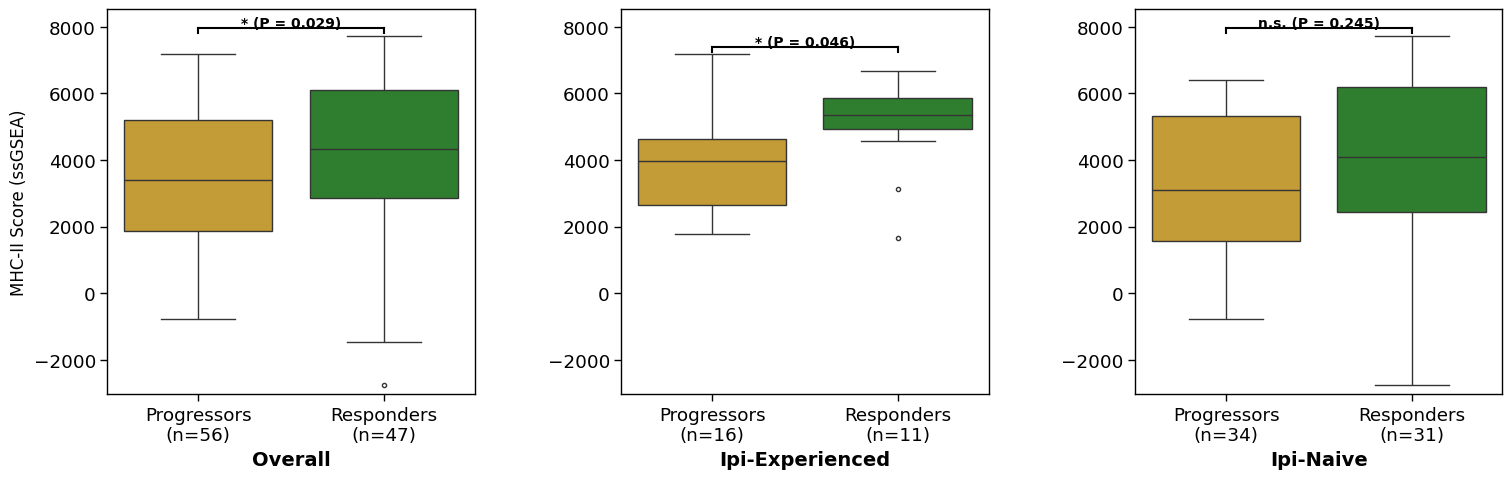

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu

# --- CONSTANTS ---
RESPONDER_COL = "forestgreen"
NRESPONDER_COL = "goldenrod"

sig = 'MHC-II' # Tên cột chữ ký
outcomes = ['RvsPD', 'RvsPD-ipi-exp', 'RvsPD-ipi-naive']

# --- DATA STRUCTURES (Assumed fullDF_ssGSEA is defined elsewhere) ---
plot_specs = {
    'RvsPD': {
        'df': fullDF_ssGSEA,
        'title_suffix': 'Overall',
        'group_col': 'PD vs Responder',
        'group1_val': 'Progressor',
        'group2_val': 'Responder',
        'label1': 'Progressors',
        'label2': 'Responders'
    },
    'RvsPD-ipi-exp': {
        'df': fullDF_ssGSEA[fullDF_ssGSEA["daysBiopsyAfterIpiStart"] == "postIpi"],
        'title_suffix': 'Ipi-Experienced',
        'group_col': 'PD vs Responder',
        'group1_val': 'Progressor',
        'group2_val': 'Responder',
        'label1': 'Progressors',
        'label2': 'Responders'
    },
    'RvsPD-ipi-naive': {
        'df': fullDF_ssGSEA[fullDF_ssGSEA["daysBiopsyAfterIpiStart"] == "noIpi"],
        'title_suffix': 'Ipi-Naive',
        'group_col': 'PD vs Responder',
        'group1_val': 'Progressor',
        'group2_val': 'Responder',
        'label1': 'Progressors',
        'label2': 'Responders'
    }
}

# --- P-VALUE FORMATTING AND LINE FUNCTION ---
def format_pvalue_and_line(ax, pvalue, y_max_data):
    """
    Adds the statistical annotation line and formatted P-value to the plot.
    Returns the maximum y-limit needed for the plot.
    """
    stars = ""
    if pvalue < 0.001:
        stars = "***"
    elif pvalue < 0.01:
        stars = "**"
    elif pvalue < 0.05:
        stars = "*"
        
    # Format P-value text
    if pvalue < 0.001:
        text = f"{stars} (P < 0.001)"
    elif pvalue < 0.05:
        text = f"{stars} (P = {pvalue:.3f})"
    else:
        text = f"n.s. (P = {pvalue:.3f})"
        
    # Define vertical and text positioning based on max data value
    offset_from_max = y_max_data * 0.03
    text_spacing = y_max_data * 0.02 
    
    y_line = y_max_data + offset_from_max
    y_text = y_line + text_spacing
    
    x1, x2 = 0, 1 # Boxplot positions
    
    # 3a. Draw vertical bars
    bar_height = y_max_data * 0.02
    ax.plot([x1, x1], [y_line, y_line - bar_height], lw=1.5, c='k') 
    ax.plot([x2, x2], [y_line, y_line - bar_height], lw=1.5, c='k') 
    
    # 3b. Draw horizontal line
    ax.plot([x1, x2], [y_line, y_line], lw=1.5, c='k')

    # 3c. Draw P-value text
    ax.text((x1 + x2) / 2, y_text, text, 
            ha='center', 
            va='center', 
            fontsize=10, 
            color='k', 
            fontweight='bold')
            
    return y_text * 1.05 # Return the new suggested max y-limit

# --- PLOTTING SETUP ---
ncols = len(outcomes)
nrows = 1
gs = gridspec.GridSpec(nrows, ncols, wspace=0.4, hspace = 0.4)

fig = plt.figure(figsize=(6*ncols, 5))
sns.set_context("paper", font_scale=1.5)

# --- FIX 1: Initialize list to store all subplot axes ---
all_axes = [] 

i = 0
y_lim_max = 0

for outcome in outcomes:
    ax = plt.subplot(gs[i])
    spec = plot_specs[outcome]
    
    current_df = spec['df']
    group1_df = current_df[current_df[spec['group_col']] == spec['group1_val']]
    group2_df = current_df[current_df[spec['group_col']] == spec['group2_val']]

    # 1. TÍNH TOÁN P-VALUE và N
    mhcii_score_g1 = group1_df[sig].values.tolist()
    mhcii_score_g2 = group2_df[sig].values.tolist()
    
    if len(mhcii_score_g1) > 0 and len(mhcii_score_g2) > 0:
        # Mann-Whitney U test (assuming group2 is expected to be greater)
        _, pvalue = mannwhitneyu(mhcii_score_g2, mhcii_score_g1, alternative = "two-sided") 
    else:
        pvalue = np.nan
    
    n1 = len(mhcii_score_g1)
    n2 = len(mhcii_score_g2)
    
    # 2. CHUẨN BỊ DATAFRAME VẼ (graphDF)
    group1label = spec['label1'] + '\n(n=' + str(n1) + ')'
    group2label = spec['label2'] + '\n(n=' + str(n2) + ')'
    
    plot_df = pd.DataFrame({
        sig: group1_df[sig].tolist() + group2_df[sig].tolist(),
        'GroupLabel': [group1label] * n1 + [group2label] * n2
    })
    
    # 3. VẼ BOXPLOT
    sns.boxplot(x = 'GroupLabel', y = sig, data=plot_df, 
                order=[group1label, group2label],
                palette = [NRESPONDER_COL, RESPONDER_COL],
                fliersize=3,
                ax=ax)
    
    # 4. VẼ THANH P-VALUE VÀ CHÚ THÍCH
    if not np.isnan(pvalue):
        max_y_current = plot_df[sig].max() 
        y_max_annotated = format_pvalue_and_line(ax, pvalue, max_y_current)
        # Update the overall maximum Y-limit needed
        y_lim_max = max(y_lim_max, y_max_annotated)
    
    # 5. ĐỊNH DẠNG TRỤC
    ax.set_xlabel(spec['title_suffix'], fontsize=14, fontweight='bold')
    
    if i == 0:
        ax.set_ylabel(f'{sig} Score (ssGSEA)', fontsize=12)
    else:
        ax.set_ylabel('')

    plt.xticks(rotation=0)
    
    # --- FIX 2: Collect the current axis object ---
    all_axes.append(ax)
    
    i += 1

# --- FIX 3: Apply common Y-limit to all collected axes ---
# Calculate the minimum Y-data limit once
min_y_data = fullDF_ssGSEA[sig].min()
# Set a slightly adjusted minimum Y limit for aesthetics
y_min_plot = min_y_data * 0.9 if min_y_data > 0 else min_y_data * 1.1

for ax in all_axes:
    # Use the globally calculated y_lim_max from the p-value annotations
    ax.set_ylim(y_min_plot, y_lim_max) 

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [30]:
GRAY = (0.95, 0.95, 0.95, 1)
LIGHT_BLUE = (0.65098041296005249, 0.80784314870834351, 0.89019608497619629, 1.0)
BLUE = (0.12572087695201239, 0.47323337360924367, 0.707327968232772, 1.0)
LIGHT_GREEN = (0.68899655751153521, 0.8681737867056154, 0.54376011946622071, 1.0)
GREEN = (0.21171857311445125, 0.63326415104024547, 0.1812226118410335, 1.0)
PINK = (0.98320646005518297, 0.5980161709820524, 0.59423301088459368, 1.0)
RED = (0.89059593116535862, 0.10449827132271793, 0.11108035462744099, 1.0)
LIGHT_ORANGE = (0.99175701702342312, 0.74648213716698619, 0.43401768935077328, 1.0)
ORANGE = (0.99990772780250103, 0.50099192647372981, 0.0051211073118098693, 1.0)
LIGHT_PURPLE = (0.78329874347238004, 0.68724338552531095, 0.8336793640080622, 1.0)
PURPLE = (0.42485198495434734, 0.2511495584950722, 0.60386007743723258, 1.0)
YELLOW = (0.99760092286502611, 0.99489427150464516, 0.5965244373854468, 1.0)
LIGHT_BROWN = (0.9, 0.6, 0.5, 1.0)
BROWN = (0.69411766529083252, 0.3490196168422699, 0.15686275064945221, 1.0)

YELLOW = (255/256.,255/256.,51/256.,1.0)
BLUE = (55/256.,126/256.,184/256.,1.0)
PURPLE = (152/256.,78/256.,163/256.,1.0)
RED = (228/256.,26/256.,28/256.,1.0)
GREEN = (77/256.,175/256.,74/256.,1.0)
BROWN = (166/256.,86/256.,40/256.,1.0)
ORANGE = (255/256.,127/256.,0,1.0)
GRAY = (0.95, 0.95, 0.95, 1.0)
PRIMARY_SIG_COLORS = [GRAY, LIGHT_GREEN, YELLOW, LIGHT_PURPLE, LIGHT_BLUE, LIGHT_ORANGE, BLUE, RED]
def PlotStackedBarPlot(barPlot, df_nonnorm, sigOrder = None, xlabel = False, colorList = PRIMARY_SIG_COLORS, 
                       normalize = False, legendSize = 50):
    numSamples = len(df_nonnorm.columns)
    numClasses = len(df_nonnorm)

#    plt.figure(figsize=(30,10))

    if normalize: 
        # normalize data
        df = df_nonnorm/df_nonnorm.apply(sum, axis = 0)
    else:
        df = df_nonnorm

    # set order
    if sigOrder is None: # set signature order to default order
        sigOrder = df_nonnorm.index    
    df = df.loc[sigOrder]
    
    # generate the bottoms of each of the stacked values
    bottom = [np.array([0] * numSamples)]
    for i in range(0, numClasses):
        bottom.append(bottom[i] + np.array(df.iloc[i,:]))
    
    ind = np.arange(numSamples)
    width = 0.5
    bargraphs = []
    
    for i in range(0, numClasses):
        bargraphs.append(plt.bar(ind, df.iloc[i,:], width, bottom = bottom[i], color = colorList[i+1]))

    # label x axis
    if xlabel:
        plt.setp(barPlot.get_xticklabels(), visible=True)
        plt.xticks(ind, df.columns, rotation = 'vertical')
#        barPlot.get_xaxis().set_ticks(ind + width/2., df.columns, rotation = 'vertical')
    else:
        plt.setp(barPlot.get_xticklabels(), visible=False)

    # Limit x axis
    plt.xlim(-0.5, numSamples-0.5)
        
#        barPlot.get_xaxis().set_ticks(ind + width/2., [])
    
    # label y axis
    barPlot.get_yaxis().set_label("Mutations")
    
    
    # Legend
    if legendSize is not None:
        barPlot.legend([x[0] for x in bargraphs[::-1]], sigOrder[::-1], prop = {'size':legendSize}, 
                        bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [39]:
fullDF_4 = pd.concat([fullDF, res_wide], axis = 1)

# generate MHC-II upper (above median) and MHC-II lower (below median) groups
medianMHCII = fullDF_4["MHC-II"].median()
# medianMHCII = 6990.524689
upperMHCII = list(fullDF_4.loc[fullDF_4["MHC-II"]>=medianMHCII].index)
lowerMHCII = list(fullDF_4.loc[fullDF_4["MHC-II"]<medianMHCII].index)

postIpi = fullDF_4[fullDF_4["daysBiopsyAfterIpiStart"]=="postIpi"].index
noIpi = fullDF_4[fullDF_4["daysBiopsyAfterIpiStart"]=="noIpi"].index
ipiExpUpperMHCII = [x for x in postIpi if x in upperMHCII]
ipiExpLowerMHCII = [x for x in postIpi if x in lowerMHCII]
ipiNaiveUpperMHCII = [x for x in noIpi if x in upperMHCII]
ipiNaiveLowerMHCII = [x for x in noIpi if x in lowerMHCII]
print("MHCII", medianMHCII, len(upperMHCII), len(lowerMHCII), len(ipiExpUpperMHCII),len(ipiExpLowerMHCII),len(ipiNaiveUpperMHCII),len(ipiNaiveLowerMHCII))

MHCII 4058.238170230592 61 60 21 13 37 38


[[28, 19], [23, 33]]
MHC-II R vs. PD: p = 0.07617490311145005 (Fisher)
MHC-II R vs. PD: OR =  2.11441647597254
[[9, 2], [7, 9]]
Ipi-Exp MHC-II R vs. PD: p = 0.10902319737963835 (Fisher)
Ipi-Exp MHC-II R vs. PD: OR =  5.785714285714286
[[17, 14], [15, 19]]
Ipi-Naive MHC-II R vs. PD: p = 0.4602970190306581 (Fisher)
Ipi-Naive MHC-II R vs. PD: OR =  1.5380952380952382


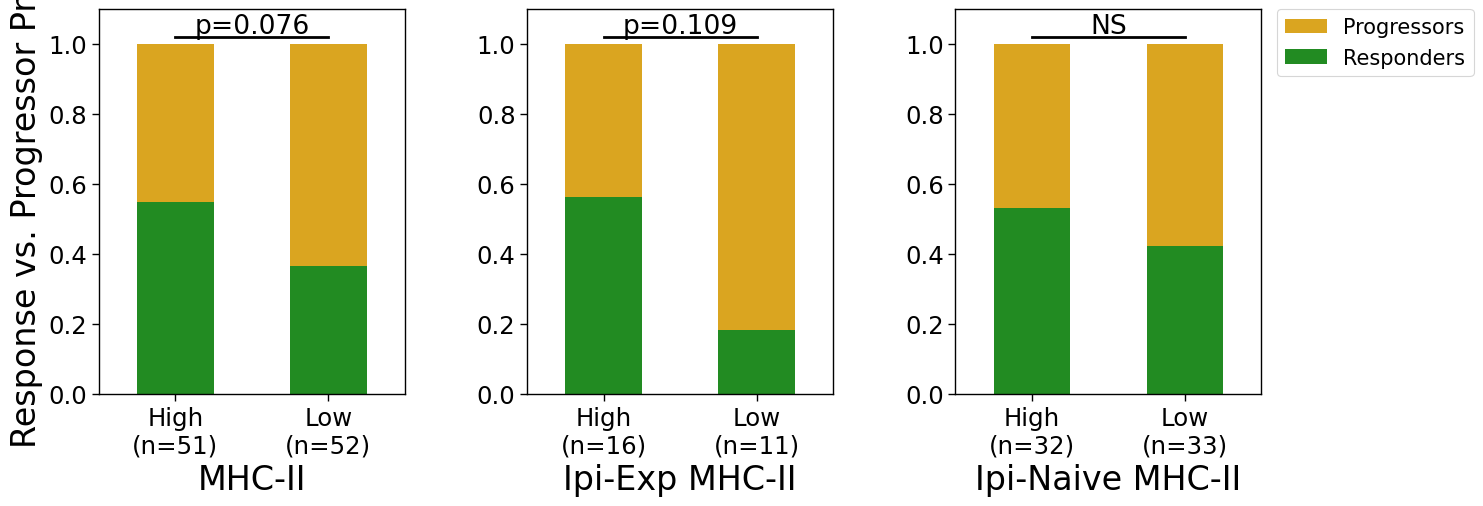

In [40]:
# Fig 4abc - proportion of responders/progressors based on high/low MHC-II expression (median split)
# in the overall, ipi-experienced, and ipi-naive cohort.
import scipy.stats as stats
phenotype = "PD vs Responder"
cohort = ~fullDF_4[phenotype].isnull() # either Responder (CR,PR) or (PD)

groups = ['MHC-II', 'Ipi-Exp MHC-II', 'Ipi-Naive MHC-II']

tempDF = fullDF_4[cohort][['Responder']]
comparisonGroups = {'MHC-II':[upperMHCII, lowerMHCII],
                   'Ipi-Exp MHC-II':[ipiExpUpperMHCII, ipiExpLowerMHCII],
                   'Ipi-Naive MHC-II':[ipiNaiveUpperMHCII, ipiNaiveLowerMHCII]}
                   # 'Absolute score':[upperAS, lowerAS],
                   # 'Ipi-Naive Absolute score':[ipiNaiveUpperAS, ipiNaiveLowerAS],
                   # 'Ipi-Exp Absolute score':[ipiExpUpperAS, ipiExpLowerAS]}

ncols = len(groups)
nrows = 1
gs = gridspec.GridSpec(nrows,ncols, #height_ratios = [1, ], width_ratios = [1,1,1], 
                       wspace=0.4, hspace = 0.4)

fig = plt.figure(figsize=(5*ncols,5))
sns.set_context("paper",font_scale=2)

i = 0
for group in groups:
    ax = plt.subplot(gs[i])
    upper = comparisonGroups[group][0]
    lower = comparisonGroups[group][1]
    upperResponders = sum((tempDF['Responder']==1)&(tempDF.index.isin(upper)))
    upperNonresponders = sum((tempDF['Responder']==0)&(tempDF.index.isin(upper)))
    lowerResponders = sum((tempDF['Responder']==1)&(tempDF.index.isin(lower)))
    lowerNonresponders = sum((tempDF['Responder']==0)&(tempDF.index.isin(lower)))
    graphDF = pd.DataFrame([[upperResponders,
                       upperNonresponders],
                       [lowerResponders,
                       lowerNonresponders]], 
                       index = ['High', 'Low'],
                      columns = ['Responders', 'Progressors']).transpose()

    orderedCategories = {
                    'MHC-II':['High', 'Low'],
                    'Ipi-Exp MHC-II':['High', 'Low'],
                    'Ipi-Naive MHC-II':['High', 'Low']}
                    # 'Absolute score':['High','Low'],
                    # 'Ipi-Exp Absolute score':['High','Low'],
                    # 'Ipi-Naive Absolute score':['High','Low']}

    if group in orderedCategories:
        groupOrder = orderedCategories[group]
    else:
        groupOrder = graphDF.columns
    colorList = [GRAY, RESPONDER_COL, NRESPONDER_COL]

    categories = ['Responders', 'Progressors']
    if i == len(groups) - 1: # only display if last one
        legendSize = 15
    else:
        legendSize = None # 
        
    PlotStackedBarPlot(ax, graphDF.loc[categories, groupOrder], xlabel=True, sigOrder = categories, normalize=True, 
                    colorList=colorList,legendSize=legendSize)
    plt.xlabel(group, fontsize=24)
    xlabels = []
    for label in groupOrder:
        total = graphDF[label].sum()
        xlabels += [label + "\n(n=" + str(total)+")"]
    ax.set_xticklabels(xlabels,rotation=0)
    if i == 0:
        plt.ylabel("Response vs. Progressor Prop", fontsize=24)
    
    # statistically compare values
    fishersMatrix = [[graphDF.loc['Responders', 'High'], graphDF.loc['Responders', 'Low']], 
                        [graphDF.loc['Progressors', 'High'], graphDF.loc['Progressors', 'Low']]]
    print(fishersMatrix)
    oddsratio, pval_fisher = stats.fisher_exact(fishersMatrix)
       
    print(group, "R vs. PD: p =", pval_fisher, "(Fisher)")
    print(group, "R vs. PD: OR = ", oddsratio )

    # plot the significance comparison
    sig = "NS"
    if pval_fisher <= 0.15:
        sig = "p=" + "{:.3f}".format(pval_fisher)
    if pval_fisher <= 0.05:
        sig = "*"
    if pval_fisher <= 0.01:
        sig = "**"
    if pval_fisher <= 0.001:
        sig = "***"
    
    yMax = 1
    plt.plot([0,1],[yMax * 1.02,yMax * 1.02], lw=2, color="black")  
   
    plt.text(0.5,yMax * 1.03,sig, ha='center')
    plt.ylim(0,yMax * 1.1)

    i+=1

## Integrative Model

In [55]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

In [56]:
res_wide = res_wide.astype(float)
quantVars = [
            'log nonsyn mutload',
              'heterogeneity',
              'purity',
                'ploidy',
               'Tx_Start_LDH',
                ]

categVars = [
                'LN_Met',
            ]

# generate response groups stratified by prior ipilimumab treatment status
# Generate a category for allRNADF to compare nonresponders (ipi-experienced) vs nonresponders (ipi-naive)
ipiTreated = fullDF[fullDF["daysBiopsyAfterIpiStart"]!="noIpi"].index
postIpi = list(fullDF[fullDF["daysBiopsyAfterIpiStart"]=="postIpi"].index)
preIpi = list(fullDF[fullDF["daysBiopsyAfterIpiStart"]=="preIpi"].index)
noIpi = list(fullDF[fullDF["daysBiopsyAfterIpiStart"]=="noIpi"].index)


PDpostIpi = list(set(postIpi).intersection(set(progressors)))
PDnoIpi = list(set(noIpi).intersection(set(progressors)))
RpostIpi = list(set(postIpi).intersection(set(responders)))
RnoIpi = list(set(noIpi).intersection(set(responders)))
nPDpostIpi = [x for x in postIpi if x not in progressors] 
nPDnoIpi = [x for x in noIpi if x not in progressors] 

# create a set of regression DFs for each comparison and cohort, e.g. regDFs['Ipi-exp PDvsnPD']
regDFs = {}

# generate regression DF for hallmark signatures
variables = res_wide.columns 
outcomeGroups = {'Ipi-exp PD vs nPD': [PDpostIpi, nPDpostIpi],
                'Ipi-naive PD vs nPD': [PDnoIpi, nPDnoIpi],
                 'PD vs nPD': [progressors, nonprogressors],
                }
for outcome in outcomeGroups:
    group1 = [x for x in outcomeGroups[outcome][0] if x in res_wide.index]
    group0 = [x for x in outcomeGroups[outcome][1] if x in res_wide.index]
    tempDF = res_wide.copy()
    tempDF.loc[group1, 'outcome'] = 1
    tempDF.loc[group0, 'outcome'] = 0
    # remove rows with 'na' as outcome
    tempDF = tempDF[~tempDF['outcome'].isnull()]
    regDFs[outcome] = tempDF
    print(outcome,":",len(tempDF.index),'patients and', len(tempDF.columns),'signatures')

Ipi-exp PD vs nPD : 27 patients and 53 signatures
Ipi-naive PD vs nPD : 85 patients and 53 signatures
PD vs nPD : 121 patients and 53 signatures


In [57]:
# GenRegDF
# -----------
# given a dataset, outcome of interest, categorical and continuous variables
# generates a standardized df with each continuous variable scaled
# from 0-1 and also binary variables for Q1, Q4, upper and lower
# halves of quantitative variables.

def GenRegDF (df, categVars, quantVars, outcome = None):
    # grab the patients with valid outcomes
    if outcome is not None:
        regDF = df[df[outcome].apply(np.isreal) & ~df[outcome].isnull()][[outcome] + quantVars] # get ones with outcomes
    else:
        regDF = df[quantVars]
        
    nullQuants = []
    for quantVar in quantVars:
        # clean up quantitative variables for missing values and non-quantitative values
        regDF.loc[regDF.index, quantVar] = pd.to_numeric(regDF[quantVar], errors = 'coerce') # convert to numeric, NaN if not numeric
        if sum(regDF[quantVar].isnull()) > 0:
            print(quantVar,"has", sum(regDF[quantVar].isnull()),"null values")
            nullQuants += [quantVar]

        median = regDF[quantVar].median()
        print(quantVar, "median:", median)
        aboveMedian = regDF[quantVar] > median
        belowMedian = regDF[quantVar] <= median

        regDF.loc[:,quantVar + "_upper"] = 0
        regDF.loc[aboveMedian, quantVar + "_upper"] = 1

        regDF.loc[:,quantVar + "_lower"] = 0
        regDF.loc[belowMedian, quantVar + "_lower"] = 1

    # generate dummy variables for categorical variables
    for categVar in categVars:
        dummyDF = pd.get_dummies(df[categVar], prefix=categVar)
        cols = dummyDF.columns
        regDF = regDF.merge(dummyDF.iloc[:,1:], left_index=True, right_index = True)

    # rescale variables
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0,1))
    goodFeatures = [x for x in regDF.columns if x not in nullQuants]
    tempDF = pd.DataFrame(scaler.fit_transform(regDF[goodFeatures]), index = regDF.index, columns = goodFeatures)
    tempDF[nullQuants] = regDF[nullQuants] # pass through without scaling
    regDF = tempDF

    # generate intercept
    regDF['intercept'] = 1

    print("Total variables in regression DF:", len(regDF.columns) - 1)
    return regDF

In [58]:
# generate regDFs
fullRegDFs = {}
outcomeGroups = ['Ipi-exp PD vs nPD',
                 'Ipi-naive PD vs nPD',
                'PD vs nPD',
                ]
for outcome in outcomeGroups:
    regDF = regDFs[outcome]

    print(len(regDF.index),"entries in regDF")

    # generate the regDF for DNA and clinical variables
    tempDF = GenRegDF(fullDF[categVars + quantVars], categVars, quantVars)
    print(len(tempDF.index),"entries in tempDF")

    # join with our existing DF and the single cell sigantures
    regDF = regDF.merge(tempDF, how='inner', left_index=True, right_index=True)

    # remove variables with variance 0
    regDF = regDF.loc[:,regDF.var() != 0]

    # add intercept
    regDF['intercept'] = 1

    # save off
    fullRegDFs[outcome] = regDF
    print(outcome,":",len(regDF.index),"patients and",len(regDF.columns),"features")

27 entries in regDF
log nonsyn mutload median: 2.3364597338485296
heterogeneity median: 0.177570093457943
purity median: 0.69
ploidy median: 2.13
Tx_Start_LDH median: 244.0
Total variables in regression DF: 16
121 entries in tempDF
Ipi-exp PD vs nPD : 27 patients and 70 features
85 entries in regDF
log nonsyn mutload median: 2.3364597338485296
heterogeneity median: 0.177570093457943
purity median: 0.69
ploidy median: 2.13
Tx_Start_LDH median: 244.0
Total variables in regression DF: 16
121 entries in tempDF
Ipi-naive PD vs nPD : 85 patients and 70 features
121 entries in regDF
log nonsyn mutload median: 2.3364597338485296
heterogeneity median: 0.177570093457943
purity median: 0.69
ploidy median: 2.13
Tx_Start_LDH median: 244.0
Total variables in regression DF: 16
121 entries in tempDF
PD vs nPD : 121 patients and 70 features


In [33]:
import brewer2mpl
brewer2mpl.print_maps()
COLOR_LIST = brewer2mpl.get_map('Set3', 'Qualitative', 12).mpl_colors
def CreateCoMutFig(currentPlot, df, colorList = COLOR_LIST, cmap = None, italic=False):
    numGenes = len(df)
    numSamples = len(df.columns)

    # remove initial frame
    for side in ['top', 'bottom', 'right', 'left']: 
        currentPlot.spines[side].set_visible(False)
    
    # set colors
    if cmap is None:
        cmap = mpl.colors.ListedColormap(colorList)
        vmax = len(colorList) - 1
    else:
        vmax = 1
    
    # display data
    cax = currentPlot.imshow(df, interpolation = 'none', aspect = 'auto',
                    cmap = cmap, vmin = 0, vmax = vmax)
    
    # Remove tick marks
    plt.tick_params(axis = 'both', which = 'both', 
                top = False, bottom = False, right = False, left = False)
    
    # Resize tick marks
    plt.xticks(range(0, numSamples, 1), rotation = 90)
    plt.yticks(range(0, numGenes,1), fontsize = 13)
    
    # Replace y ticks with gene names
    if italic:
        currentPlot.set_yticklabels(df.index, style = 'italic')
    else:
        currentPlot.set_yticklabels(df.index)

    currentPlot.set_xticklabels(df.columns)
 
    
    # Create white lines across the grid
    for y in range(0, numGenes, 1):  
        plt.plot(range(-1, numSamples+2), [y+0.5] * (len(range(-1, numSamples))+2), "-", 
                 lw=2, color="white", alpha=1)
    for x in range(0,numSamples+1,1):
        plt.plot([x + 0.5] * len(range(-1,numGenes+1)), range(-1,numGenes+1), "-",
                 lw=2, color="white", alpha=1)    
        
    # limit the x and y-axis to just the range
    plt.xlim(-0.5, numSamples-0.5)
    plt.ylim(-0.5, numGenes-0.5)
    
    # remove grid lines
    currentPlot.grid(False)
    return (cax)

# AddMarkersCoMutFig - creates markers at given locations; e.g. to mark germline mutations
def AddMarkersCoMutFig(currentPlot, df, colorList = COLOR_LIST):
    # get dimensions of the plot
    numSamples = len(df.columns)
    numRows = len(df)

    for i in range(0,numRows):
        for j in range(0,numSamples):
            alt = int(df.iloc[i,j])
            rect = plt.Rectangle((j-0.25, i-0.25), 0.5, 0.5, fc = colorList[alt])
            if alt != 0:
                currentPlot.add_patch(rect)
GRAY = (0.95, 0.95, 0.95, 1)
LIGHT_BLUE = (0.65098041296005249, 0.80784314870834351, 0.89019608497619629, 1.0)
BLUE = (0.12572087695201239, 0.47323337360924367, 0.707327968232772, 1.0)
LIGHT_GREEN = (0.68899655751153521, 0.8681737867056154, 0.54376011946622071, 1.0)
GREEN = (0.21171857311445125, 0.63326415104024547, 0.1812226118410335, 1.0)
PINK = (0.98320646005518297, 0.5980161709820524, 0.59423301088459368, 1.0)
RED = (0.89059593116535862, 0.10449827132271793, 0.11108035462744099, 1.0)
LIGHT_ORANGE = (0.99175701702342312, 0.74648213716698619, 0.43401768935077328, 1.0)
ORANGE = (0.99990772780250103, 0.50099192647372981, 0.0051211073118098693, 1.0)
LIGHT_PURPLE = (0.78329874347238004, 0.68724338552531095, 0.8336793640080622, 1.0)
PURPLE = (0.42485198495434734, 0.2511495584950722, 0.60386007743723258, 1.0)
YELLOW = (0.99760092286502611, 0.99489427150464516, 0.5965244373854468, 1.0)
LIGHT_BROWN = (0.9, 0.6, 0.5, 1.0)
BROWN = (0.69411766529083252, 0.3490196168422699, 0.15686275064945221, 1.0)

YELLOW = (255/256.,255/256.,51/256.,1.0)
BLUE = (55/256.,126/256.,184/256.,1.0)
PURPLE = (152/256.,78/256.,163/256.,1.0)
RED = (228/256.,26/256.,28/256.,1.0)
GREEN = (77/256.,175/256.,74/256.,1.0)
BROWN = (166/256.,86/256.,40/256.,1.0)
ORANGE = (255/256.,127/256.,0,1.0)
GRAY = (0.95, 0.95, 0.95, 1.0)

MUT_SIG_COLORS = [GRAY, LIGHT_BLUE, PINK, LIGHT_PURPLE, LIGHT_BROWN, LIGHT_GREEN, LIGHT_ORANGE]
PRIMARY_SIG_COLORS = [GRAY, LIGHT_GREEN, YELLOW, LIGHT_PURPLE, LIGHT_BLUE, LIGHT_ORANGE, BLUE, RED]

# DEFINE mutation and CNA types
MULTIPLE_MUTS = 3
SILENT = 0
MISSENSE_MUTATION = 1
TRUNCATED_MUTATION = 2
INFRAME_INDEL = 8

AMP = 6
HIGH_AMP = 7
HOMOZYGOUS_DEL = 5
LOH = 4
HOMOZYGOUS_DEL_AND_AMP = 9

# DEFINE COLORS for visualization
ALT_COLORS = {SILENT: GRAY,
             MISSENSE_MUTATION: LIGHT_GREEN,
             TRUNCATED_MUTATION: GREEN,
             MULTIPLE_MUTS: BROWN,
             LOH: LIGHT_BLUE,
             HOMOZYGOUS_DEL: BLUE,
             AMP: PINK,
             HIGH_AMP: RED,
             HOMOZYGOUS_DEL_AND_AMP:PURPLE,
             INFRAME_INDEL: LIGHT_ORANGE,
              10: "lime",
              11: "green"
            }
RESPONDER_COL = "forestgreen"
NRESPONDER_COL = "goldenrod"
SD_COL = "cornflowerblue"
CR_COL = GREEN
PR_COL = LIGHT_GREEN
PD_COL = "goldenrod"
MR_COL = PURPLE
LN_COL = PURPLE

Sequential
Blues     :  {3, 4, 5, 6, 7, 8, 9}
BuGn      :  {3, 4, 5, 6, 7, 8, 9}
BuPu      :  {3, 4, 5, 6, 7, 8, 9}
GnBu      :  {3, 4, 5, 6, 7, 8, 9}
Greens    :  {3, 4, 5, 6, 7, 8, 9}
Greys     :  {3, 4, 5, 6, 7, 8, 9}
OrRd      :  {3, 4, 5, 6, 7, 8, 9}
Oranges   :  {3, 4, 5, 6, 7, 8, 9}
PuBu      :  {3, 4, 5, 6, 7, 8, 9}
PuBuGn    :  {3, 4, 5, 6, 7, 8, 9}
PuRd      :  {3, 4, 5, 6, 7, 8, 9}
Purples   :  {3, 4, 5, 6, 7, 8, 9}
RdPu      :  {3, 4, 5, 6, 7, 8, 9}
Reds      :  {3, 4, 5, 6, 7, 8, 9}
YlGn      :  {3, 4, 5, 6, 7, 8, 9}
YlGnBu    :  {3, 4, 5, 6, 7, 8, 9}
YlOrBr    :  {3, 4, 5, 6, 7, 8, 9}
YlOrRd    :  {3, 4, 5, 6, 7, 8, 9}
Diverging
BrBG      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PRGn      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PiYG      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
PuOr      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdBu      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdGy      :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdYlBu    :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
RdYlGn    :  {3, 4, 5, 6, 7, 8, 9, 10, 11}
Spect

[None]

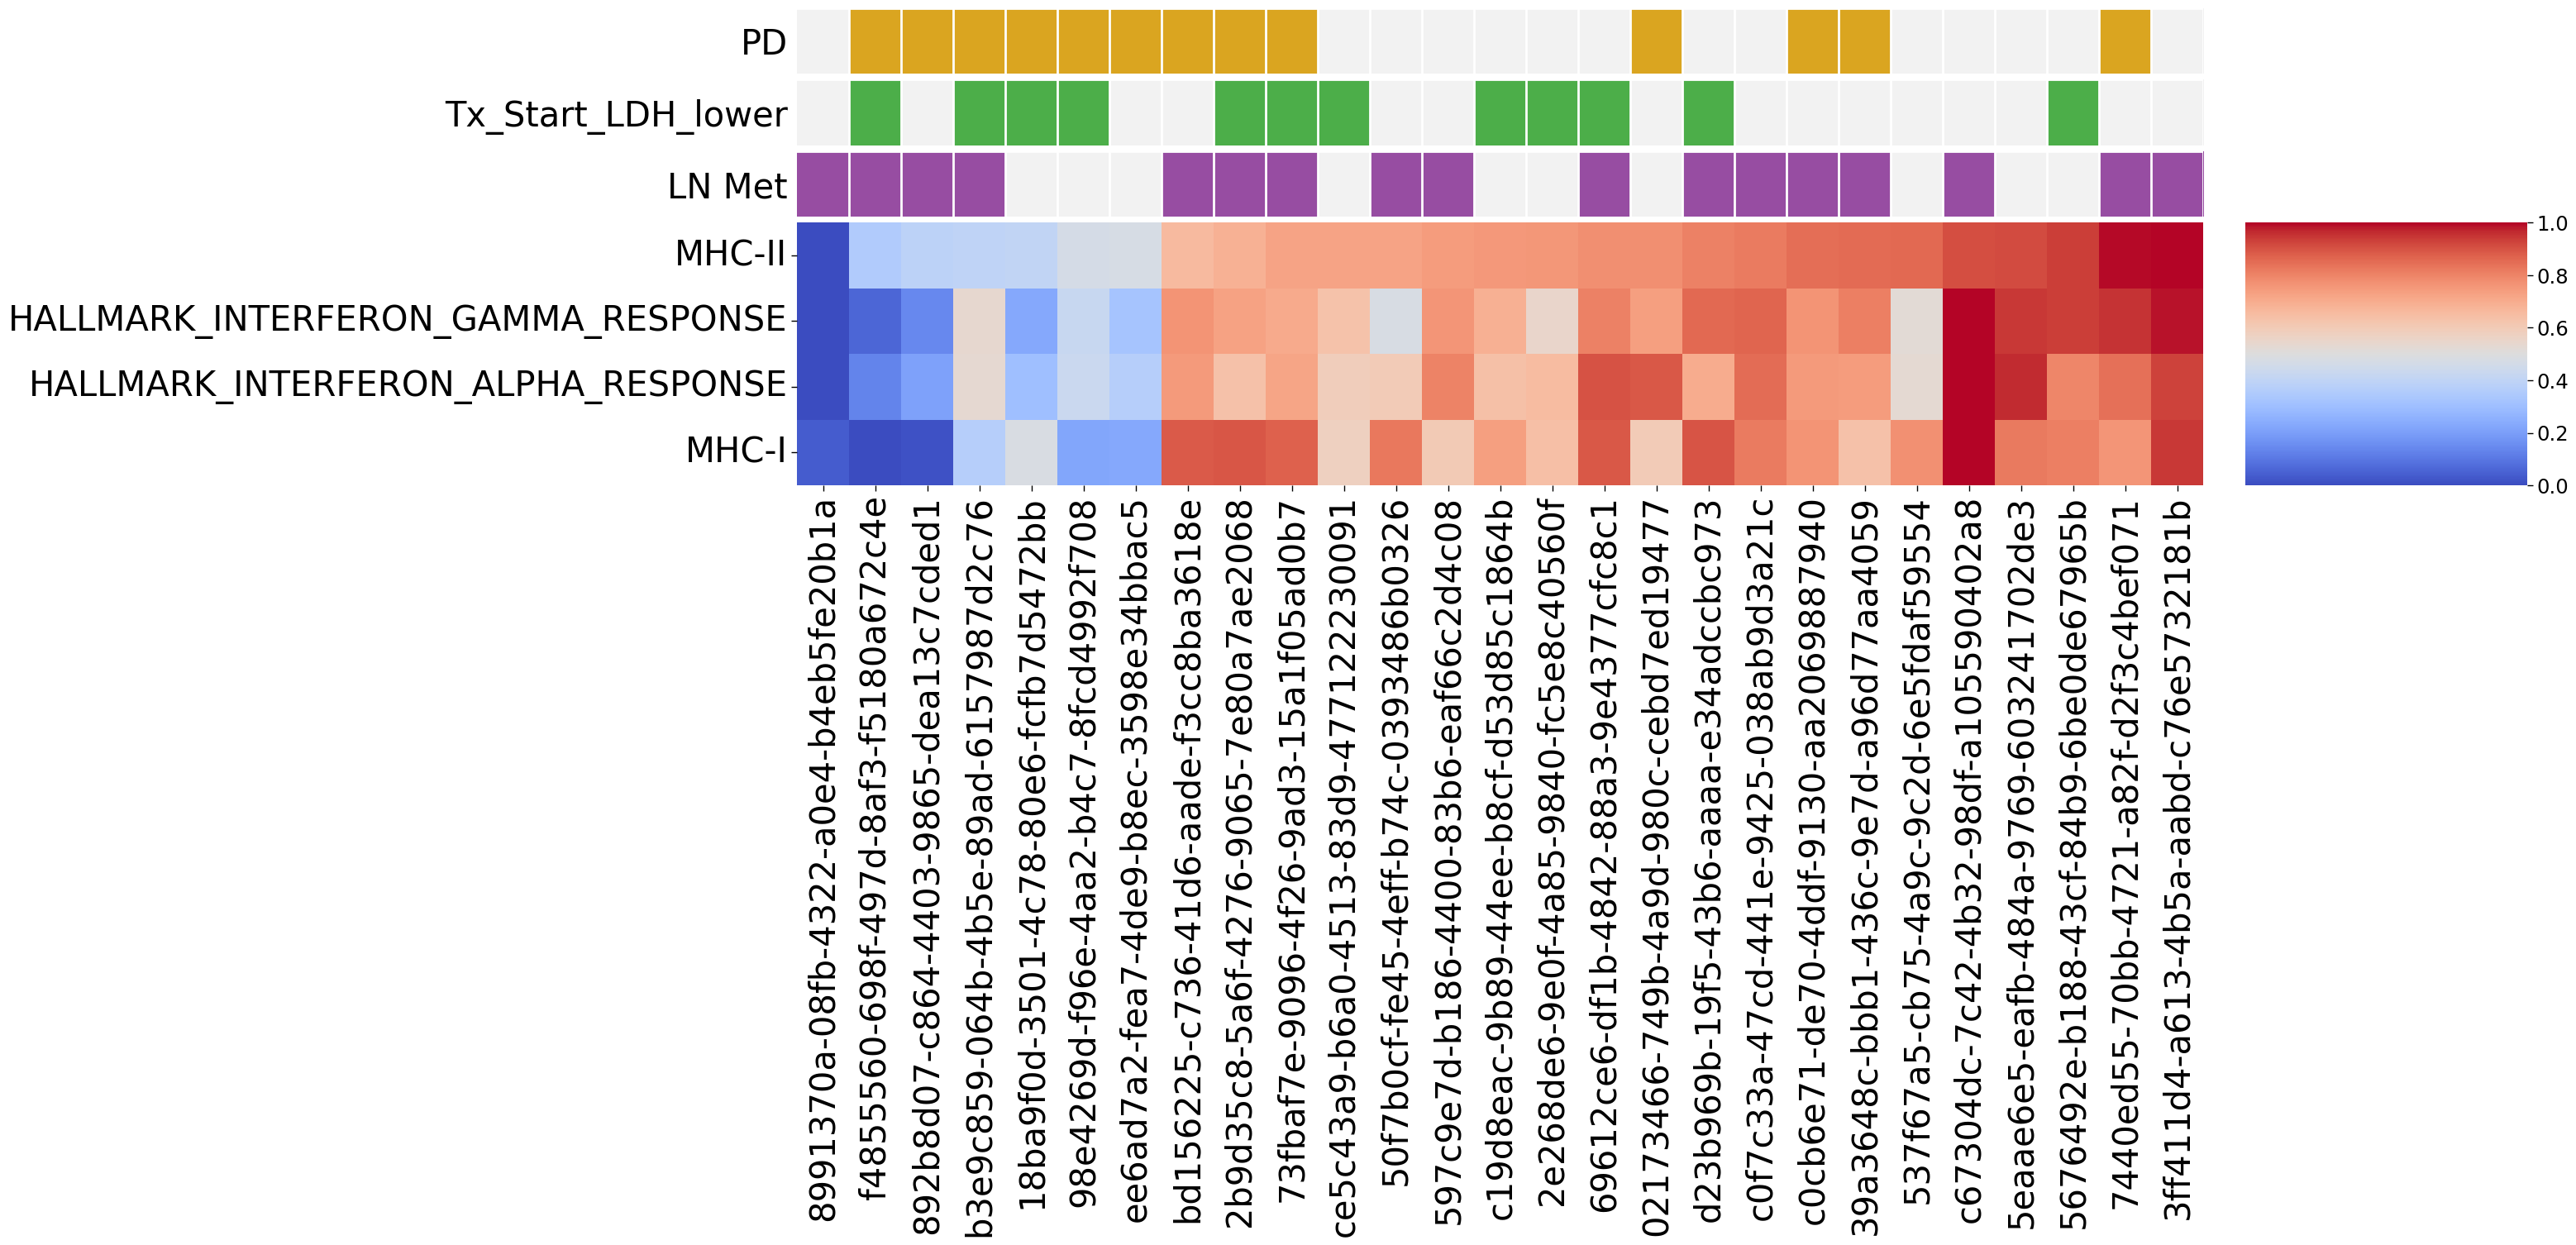

In [60]:
# Fig 5a - features that predict PD in the ipi-experienced cohort
from sklearn.preprocessing import MinMaxScaler
import matplotlib as mpl
outcome = 'Ipi-exp PD vs nPD'
geneSet = ['MHC-II', 'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_INTERFERON_ALPHA_RESPONSE',
          'MHC-I']
# additionalFeatures = ['Tx_Start_LDH_lower', 'LN_Met_1.0']
additionalFeatures = ['Tx_Start_LDH_lower', 'LN_Met_1']
regDF = fullRegDFs[outcome]
df = regDF[~regDF['outcome'].isnull()][geneSet + ['outcome'] + additionalFeatures]
scaler = MinMaxScaler(feature_range=(0,1))
df = pd.DataFrame(scaler.fit_transform(df), index = df.index, columns = df.columns)

outcomeLabel = 'PD'

#graph order by variable values
orderGenes = ['MHC-II']
sampleOrder = [df.index.get_loc(x) for x in df.sort_values(orderGenes).index]
samples = df.sort_values(orderGenes).index

#Now graph the comut plots

#reorder the geneSet
graphDF = df.iloc[sampleOrder][geneSet].transpose()

groupDF = pd.DataFrame(columns = df.index[sampleOrder])
groupDF.loc[outcomeLabel] = df.iloc[sampleOrder]['outcome']
groupDF.loc['LN Met'] = fullDF.loc[samples]['LN_Met']

groupDF.loc['Tx_Start_LDH_lower'] = df.iloc[sampleOrder]['Tx_Start_LDH_lower']
groupDF.loc['Tx_Start_LDH_lower_null'] = fullDF.loc[samples]['Tx_Start_LDH'].isin(['unknown'])

groupDF.fillna(0, inplace=True)

fig = plt.figure(figsize = (27,2.7+1.2*len(geneSet)))

nrows = 4
height_ratios = [1,1,1,1*len(geneSet)]
ncols = 2
    
gs = gridspec.GridSpec(nrows,ncols, height_ratios = height_ratios, width_ratios = [5,1], 
                           wspace=0.05, hspace = 0.05)
    
heatmapPlot = plt.subplot(gs[3,0])
cbarPlot = plt.subplot(gs[3,1])
sns.heatmap(graphDF, ax=heatmapPlot, cmap="coolwarm", cbar_ax=cbarPlot)

plt.setp(heatmapPlot.get_yticklabels(), size=30) 
plt.setp(heatmapPlot.get_xticklabels(), size=30) 


#generate response plot
groupPlot = plt.subplot(gs[0,0])
CreateCoMutFig(groupPlot, groupDF.loc[[outcomeLabel]].astype(int), [GRAY, PD_COL])
plt.setp(groupPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(groupPlot.get_yticklabels(), size=30) 

# generate LDH plot
ldhPlot = plt.subplot(gs[1,0])
CreateCoMutFig(ldhPlot, groupDF.loc[['Tx_Start_LDH_lower']].astype(int), [GRAY, CR_COL])
# set missing values
AddMarkersCoMutFig(ldhPlot, groupDF.loc[['Tx_Start_LDH_lower_null']], [GRAY, 'black'])

plt.setp(ldhPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(ldhPlot.get_yticklabels(), size=30) 


#generate lymph node met plot
lnPlot = plt.subplot(gs[2,0])

CreateCoMutFig(lnPlot, groupDF.loc[['LN Met']].astype(int), [GRAY, LN_COL])
plt.setp(lnPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(lnPlot.get_yticklabels(), size=30)

[None]

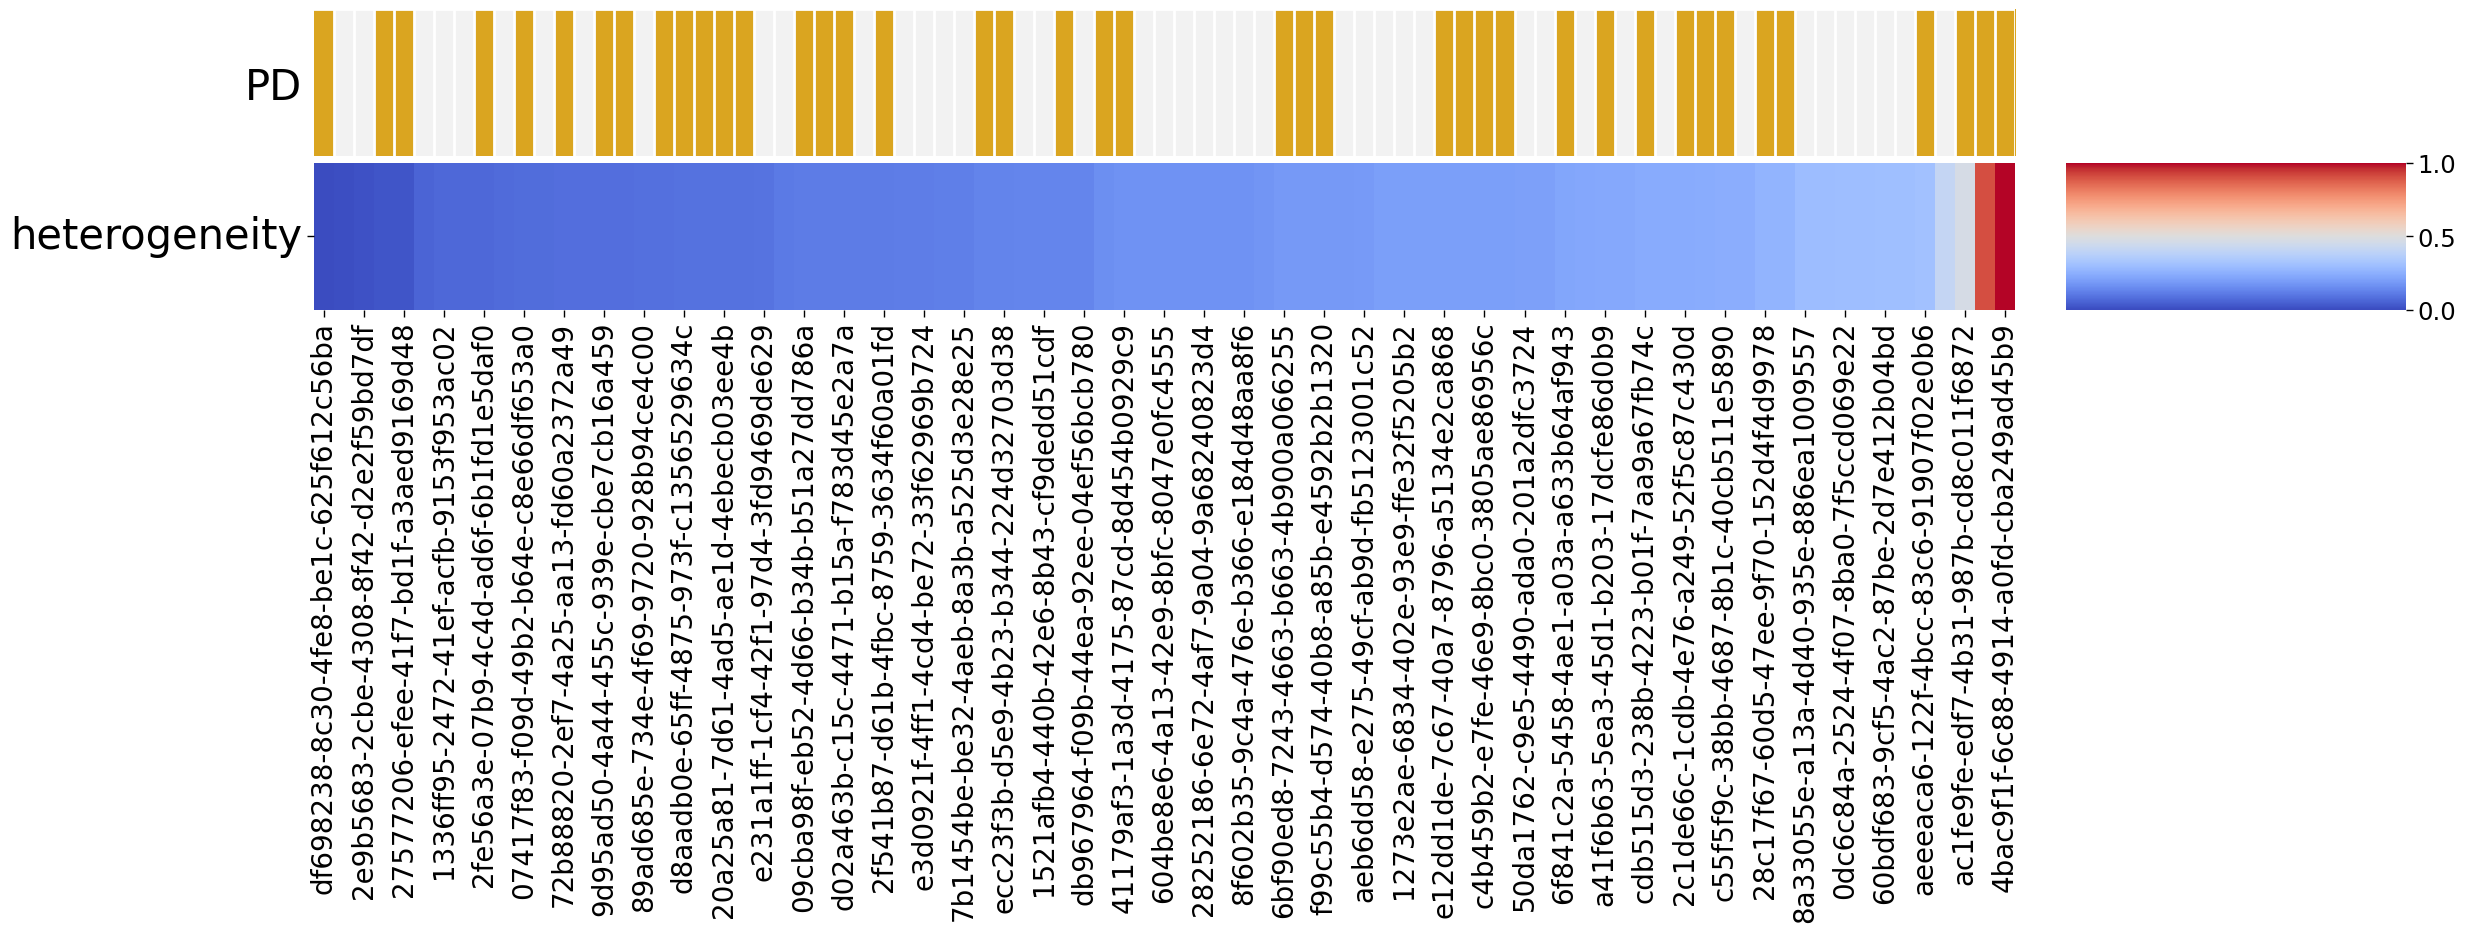

In [61]:
# Fig 5c - features that predict PD in the ipi-naive cohort
from sklearn.preprocessing import MinMaxScaler

outcome = 'Ipi-naive PD vs nPD'
geneSet = ['heterogeneity', 'ploidy', 'purity']
additionalFeatures = []
regDF = fullRegDFs[outcome]
df = regDF[~regDF['outcome'].isnull()][geneSet + ['outcome'] + additionalFeatures]
scaler = MinMaxScaler(feature_range=(0,1))
df = pd.DataFrame(scaler.fit_transform(df), index = df.index, columns = df.columns)

outcomeLabel = 'PD'

#sample order by variable value 
orderGenes = ['heterogeneity']
sampleOrder = [df.index.get_loc(x) for x in df.sort_values(orderGenes).index]
samples = df.sort_values(orderGenes).index

#Now graph the comut plots
#reorder the geneSet
orderFirst = ['heterogeneity']
geneSet = orderFirst 

groupDF = pd.DataFrame(columns = df.index[sampleOrder])
groupDF.loc[outcomeLabel] = df.iloc[sampleOrder]['outcome']

groupDF.fillna(0, inplace=True)

fig = plt.figure(figsize = (27,2.7+1.2*len(geneSet)))

nrows = 2
height_ratios = [1,1*len(geneSet)]
ncols = 2
    
gs = gridspec.GridSpec(nrows,ncols, height_ratios = height_ratios, width_ratios = [5,1], 
                           wspace=0.05, hspace = 0.05)
    
heatmapPlot = plt.subplot(gs[1,0])
cbarPlot = plt.subplot(gs[1,1])
sns.heatmap(df.loc[samples,geneSet].transpose(), ax=heatmapPlot, cmap="coolwarm", cbar_ax=cbarPlot)

plt.setp(heatmapPlot.get_yticklabels(), size=30, rotation=0) 
plt.setp(heatmapPlot.get_xticklabels(), size=20) 


#generate response plot
groupPlot = plt.subplot(gs[0,0])
CreateCoMutFig(groupPlot, groupDF.loc[[outcomeLabel]].astype(int), [GRAY, PD_COL])
plt.setp(groupPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(groupPlot.get_yticklabels(), size=30) 

[None]

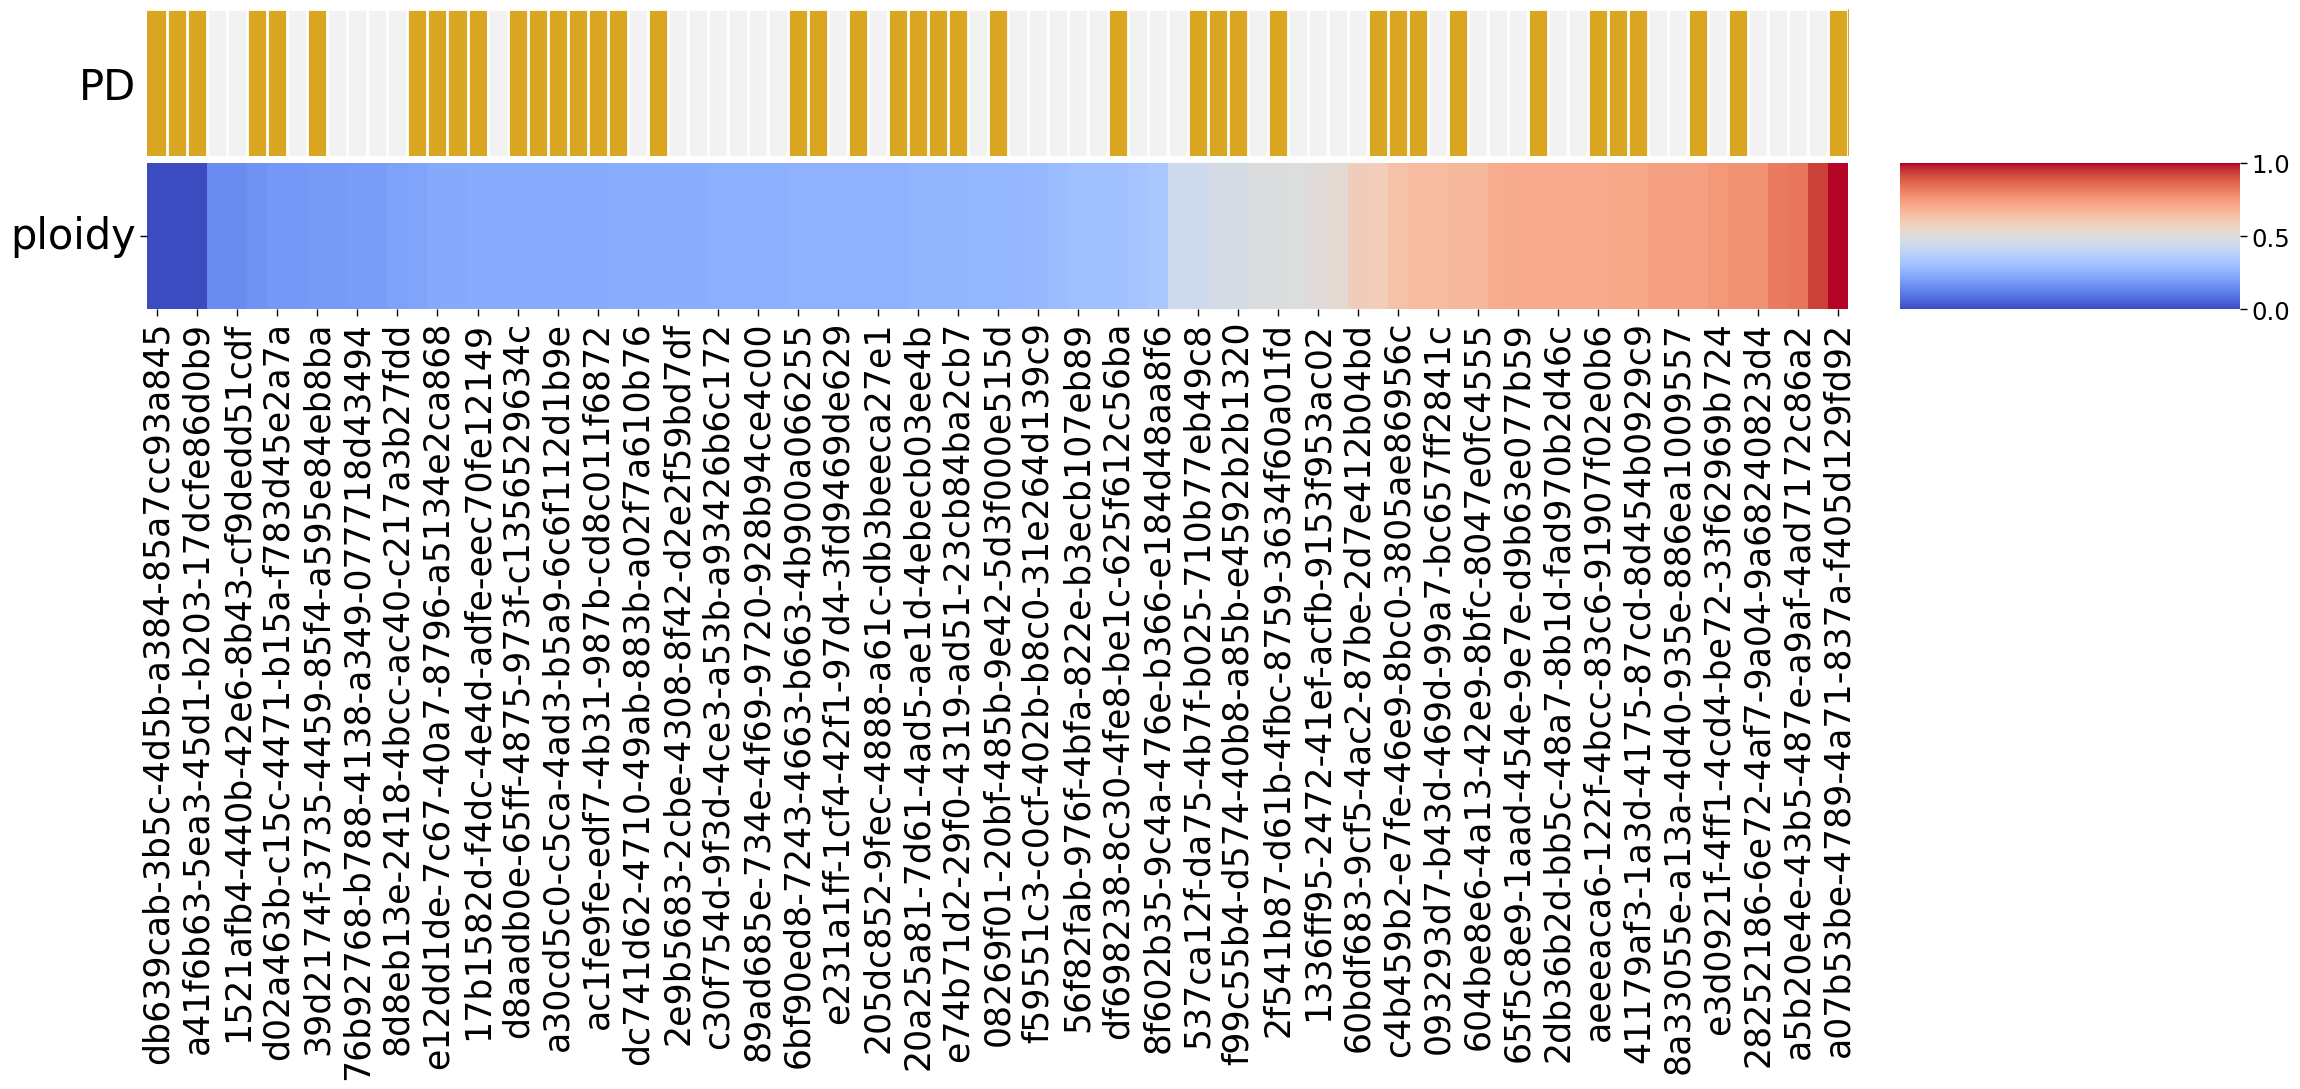

In [62]:
# Fig 5c - features that predict PD in the ipi-naive cohort
from sklearn.preprocessing import MinMaxScaler

outcome = 'Ipi-naive PD vs nPD'
geneSet = ['heterogeneity', 'ploidy', 'purity']
additionalFeatures = []
regDF = fullRegDFs[outcome]
df = regDF[~regDF['outcome'].isnull()][geneSet + ['outcome'] + additionalFeatures]
scaler = MinMaxScaler(feature_range=(0,1))
df = pd.DataFrame(scaler.fit_transform(df), index = df.index, columns = df.columns)

outcomeLabel = 'PD'

#alternately, graph order by other variable values
orderGenes = ['ploidy']
sampleOrder = [df.index.get_loc(x) for x in df.sort_values(orderGenes).index]
samples = df.sort_values(orderGenes).index

#Now graph the comut plots
#reorder the geneSet
orderFirst = ['ploidy']
geneSet = orderFirst 

groupDF = pd.DataFrame(columns = df.index[sampleOrder])
groupDF.loc[outcomeLabel] = df.iloc[sampleOrder]['outcome']

groupDF.fillna(0, inplace=True)

fig = plt.figure(figsize = (27,2.7+1.2*len(geneSet)))

nrows = 2
height_ratios = [1,1*len(geneSet)]
ncols = 2
    
gs = gridspec.GridSpec(nrows,ncols, height_ratios = height_ratios, width_ratios = [5,1], 
                           wspace=0.05, hspace = 0.05)
    
heatmapPlot = plt.subplot(gs[1,0])
cbarPlot = plt.subplot(gs[1,1])
sns.heatmap(df.loc[samples,geneSet].transpose(), ax=heatmapPlot, cmap="coolwarm", cbar_ax=cbarPlot)

plt.setp(heatmapPlot.get_yticklabels(), size=30, rotation=0) 
plt.setp(heatmapPlot.get_xticklabels(), size=25) 


#generate response plot
groupPlot = plt.subplot(gs[0,0])
CreateCoMutFig(groupPlot, groupDF.loc[[outcomeLabel]].astype(int), [GRAY, PD_COL])
plt.setp(groupPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(groupPlot.get_yticklabels(), size=30) 

[None]

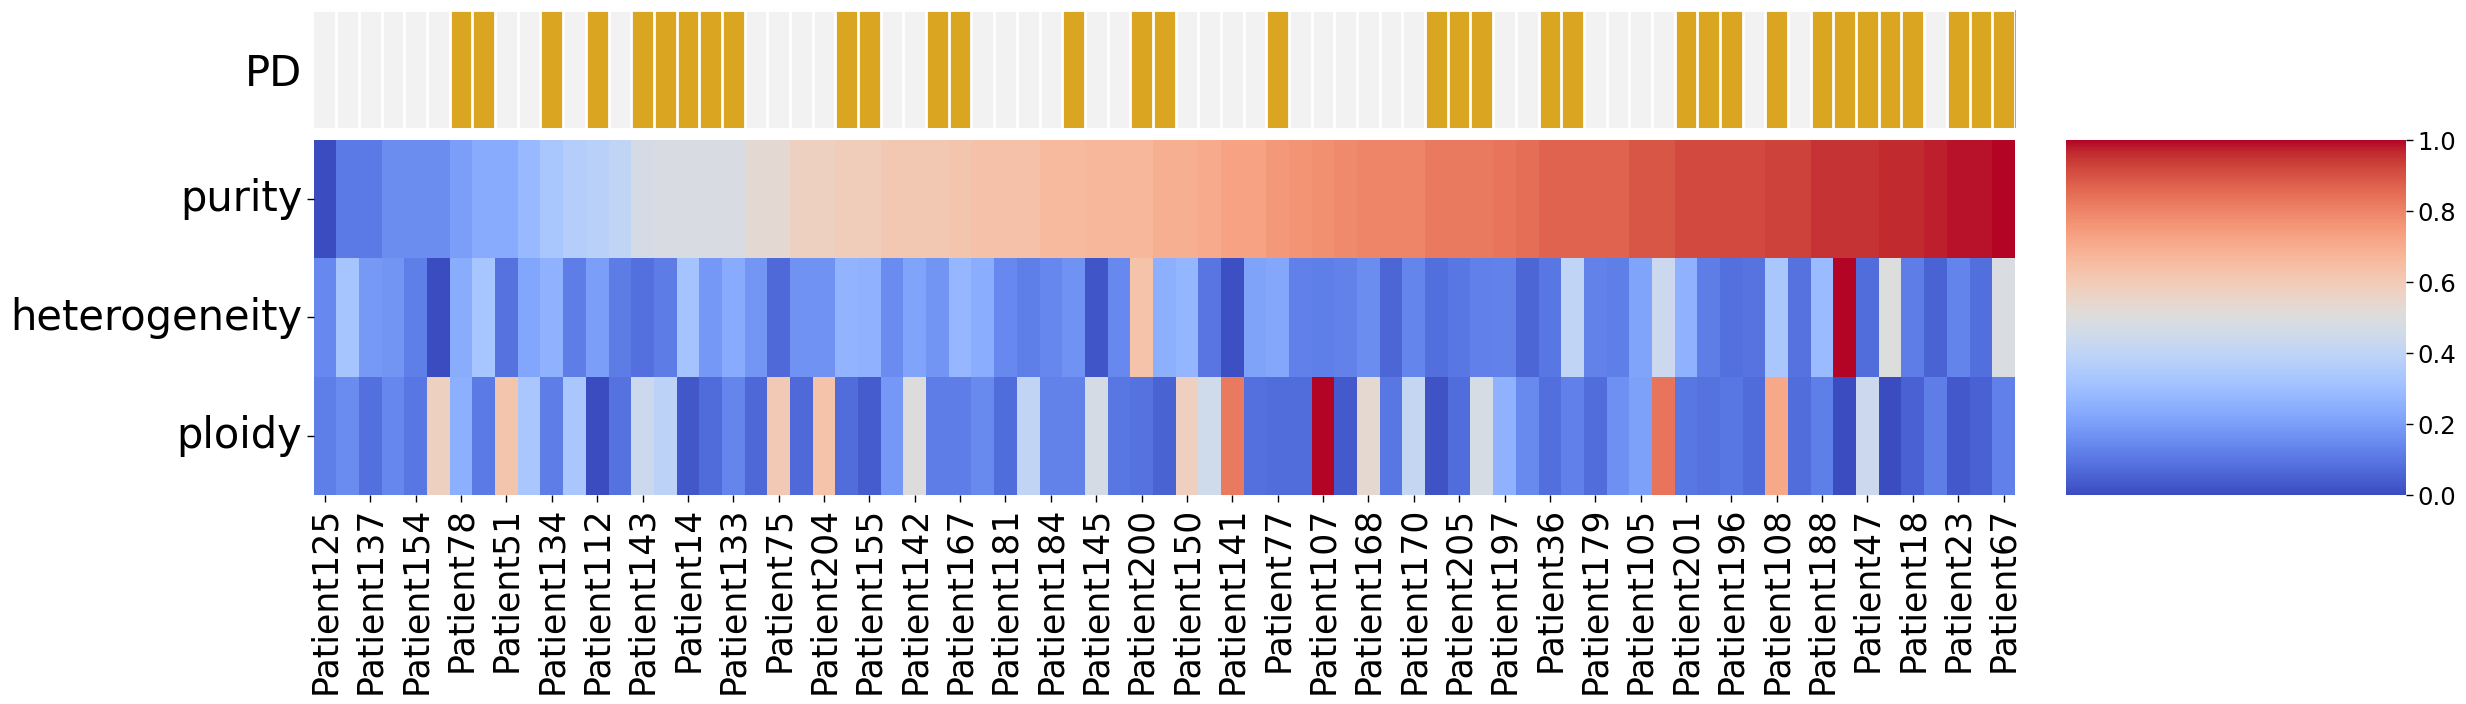

In [44]:
# Fig 5c - features that predict PD in the ipi-naive cohort
from sklearn.preprocessing import MinMaxScaler

outcome = 'Ipi-naive PD vs nPD'
geneSet = ['heterogeneity', 'ploidy', 'purity']
additionalFeatures = []
regDF = fullRegDFs[outcome]
df = regDF[~regDF['outcome'].isnull()][geneSet + ['outcome'] + additionalFeatures]
scaler = MinMaxScaler(feature_range=(0,1))
df = pd.DataFrame(scaler.fit_transform(df), index = df.index, columns = df.columns)

outcomeLabel = 'PD'

#sample order by variable value 
orderGenes = ['purity']
sampleOrder = [df.index.get_loc(x) for x in df.sort_values(orderGenes).index]
samples = df.sort_values(orderGenes).index

#Now graph the comut plots
#reorder the geneSet
orderFirst = ['purity', 'heterogeneity', 'ploidy']
geneSet = orderFirst 

groupDF = pd.DataFrame(columns = df.index[sampleOrder])
groupDF.loc[outcomeLabel] = df.iloc[sampleOrder]['outcome']

groupDF.fillna(0, inplace=True)

fig = plt.figure(figsize = (27,2.7+1.2*len(geneSet)))

nrows = 2
height_ratios = [1,1*len(geneSet)]
ncols = 2
    
gs = gridspec.GridSpec(nrows,ncols, height_ratios = height_ratios, width_ratios = [5,1], 
                           wspace=0.05, hspace = 0.05)
    
heatmapPlot = plt.subplot(gs[1,0])
cbarPlot = plt.subplot(gs[1,1])
sns.heatmap(df.loc[samples,geneSet].transpose(), ax=heatmapPlot, cmap="coolwarm", cbar_ax=cbarPlot)

plt.setp(heatmapPlot.get_yticklabels(), size=30, rotation=0) 
plt.setp(heatmapPlot.get_xticklabels(), size=25) 


#generate response plot
groupPlot = plt.subplot(gs[0,0])
CreateCoMutFig(groupPlot, groupDF.loc[[outcomeLabel]].astype(int), [GRAY, PD_COL])
plt.setp(groupPlot.get_xticklabels(), visible = False) # suppress x labels
plt.setp(groupPlot.get_yticklabels(), size=30)

Optimization terminated successfully.
         Current function value: 0.629399
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                   27
Model:                          Logit   Df Residuals:                       23
Method:                           MLE   Df Model:                            3
Date:                Mon, 24 Nov 2025   Pseudo R-squ.:                 0.09107
Time:                        23:17:45   Log-Likelihood:                -16.994
converged:                       True   LL-Null:                       -18.696
Covariance Type:            nonrobust   LLR p-value:                    0.3332
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
MHC-II                -0.0005      0.000     -1.514      0.130      -0.001       0.000
LN_Me

/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/binary/miniforge3/envs/synthetic_data/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules

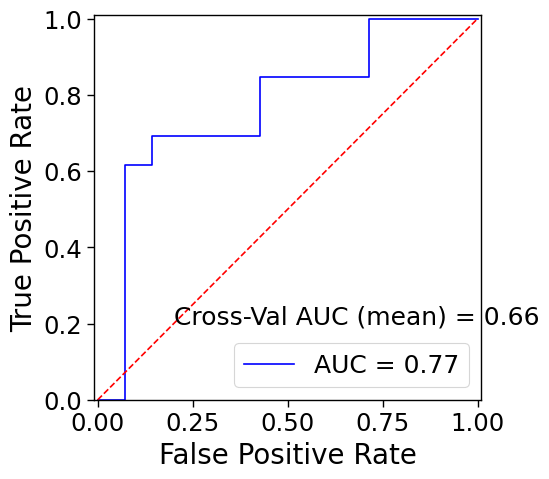

In [64]:
# Fig 5b - ROC and AUC for ipi-experienced model
outcomes = ['Ipi-exp PD vs nPD']
# features = [
#              'MHC-II',
#                 'LN_Met_1.0',
#             'Tx_Start_LDH_lower',
#            ]
features = [
             'MHC-II',
                'LN_Met_1',
            'Tx_Start_LDH_lower',
           ]

figure = plt.figure(figsize = (5,5*len(outcomes)))
nrows = len(outcomes)
ncols = 1
gs = gridspec.GridSpec(nrows,ncols, height_ratios = [1]*len(outcomes), width_ratios = [1], 
                       wspace=0.05, hspace = 0.3)

for i, outcome in enumerate(outcomes):
    regDF = fullRegDFs[outcome]
    df = regDF[~regDF['outcome'].isnull()]
    for feature in features:
        if sum(df[feature].isnull()) > 0:
            print("removing", sum(df[feature].isnull()), "samples for null", feature,"value")
        df = df[~df[feature].isnull()]
        
    # add intercept
    df['intercept'] = 1
    logitModel = sm.Logit(df['outcome'], df[features + ['intercept']])
    result = logitModel.fit()
    print(result.summary())
    auc = roc_auc_score(df['outcome'], result.predict(df[features + ['intercept']]))
    print("AUC:", auc)
    fpr, tpr, threshold = roc_curve(df['outcome'], result.predict(df[features + ['intercept']]))
    crossval_scores = cross_val_score(LogisticRegression(), df[features + ['intercept']], 
                                      df['outcome'], scoring='roc_auc', cv=5)
    print(crossval_scores, crossval_scores.mean())

    ax = plt.subplot(gs[i])
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % auc)
    plt.legend(loc = 'lower right', prop={'size':18})
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([0, 1.01])
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.text(0.2,0.2,"\nCross-Val AUC (mean) = %0.2f" % crossval_scores.mean(),size=18)

Optimization terminated successfully.
         Current function value: 0.665872
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                   85
Model:                          Logit   Df Residuals:                       81
Method:                           MLE   Df Model:                            3
Date:                Mon, 24 Nov 2025   Pseudo R-squ.:                 0.03849
Time:                        23:17:50   Log-Likelihood:                -56.599
converged:                       True   LL-Null:                       -58.865
Covariance Type:            nonrobust   LLR p-value:                    0.2096
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
purity            1.5866      1.006      1.576      0.115      -0.386       3.559
ploidy           -0.

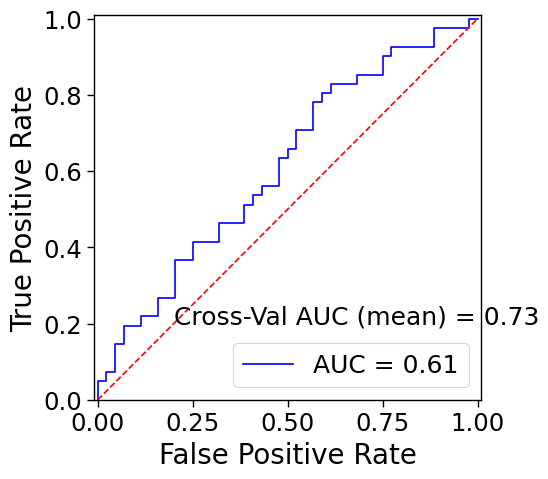

In [65]:
# Fig 5d - ROC and AUC for ipi-naive model
outcomes = ['Ipi-naive PD vs nPD']
features = [
             'purity',
                'ploidy',
            'heterogeneity',
           ]

figure = plt.figure(figsize = (5,5*len(outcomes)))
nrows = len(outcomes)
ncols = 1
gs = gridspec.GridSpec(nrows,ncols, height_ratios = [1]*len(outcomes), width_ratios = [1], 
                       wspace=0.05, hspace = 0.3)

tempRegDF = fullDF.copy()
tempRegDF['outcome'] = 0
tempRegDF.loc[progressors,'outcome'] = 1
# limit to ipinaive only
tempRegDF = tempRegDF.loc[noIpi]

for i, outcome in enumerate(outcomes):
#    regDF = fullRegDFs[outcome]
    regDF = tempRegDF
    df = regDF[~regDF['outcome'].isnull()]
    for feature in features:
        if sum(df[feature].isnull()) > 0:
            print("removing", sum(df[feature].isnull()), "samples for null", feature,"value")
        df = df[~df[feature].isnull()]
        
    # add intercept
    df['intercept'] = 1
    logitModel = sm.Logit(df['outcome'], df[features + ['intercept']])
    result = logitModel.fit()
    print(result.summary())
    auc = roc_auc_score(df['outcome'], result.predict(df[features + ['intercept']]))
    print("AUC:", auc)
    fpr, tpr, threshold = roc_curve(df['outcome'], result.predict(df[features + ['intercept']]))
    crossval_mean = 0.73
    
    ax = plt.subplot(gs[i])
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % auc)
    plt.legend(loc = 'lower right', prop={'size':18})
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([0, 1.01])
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.text(0.2,0.2,"\nCross-Val AUC (mean) = %0.2f" % crossval_mean,size=18)
    
    # cross validation auc
    crossval_scores = cross_val_score(LogisticRegression(), df[features + ['intercept']], 
                                      df['outcome'], scoring='roc_auc', cv=10)
    print(crossval_scores, crossval_scores.mean())

Optimization terminated successfully.
         Current function value: 0.629399
         Iterations 5
AUC: 0.7692307692307692
Optimization terminated successfully.
         Current function value: 0.665872
         Iterations 5
AUC: 0.6125277161862528


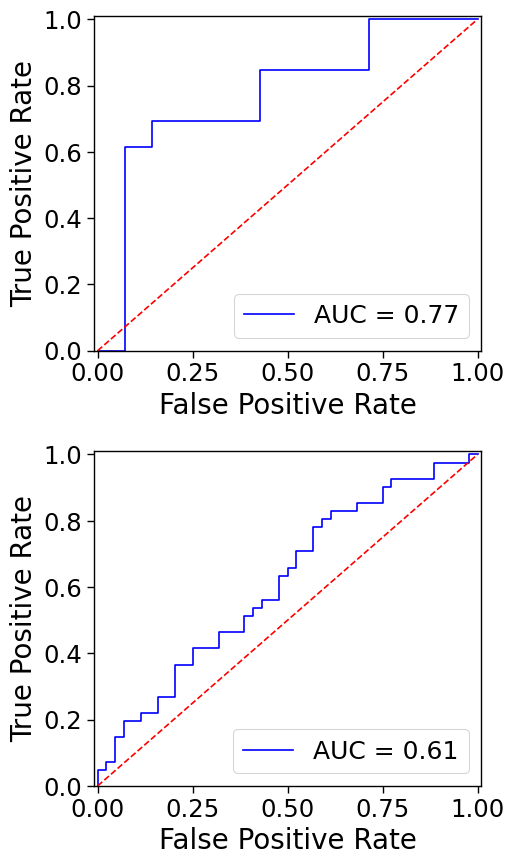

In [67]:
# Generate model scores for each outcome and model
modelScores = {}
# models applied across all tumors, split out by outcome which indicates the specific model
allTumorScores = {}

# Generate the models and AUCs for our current cohort 
outcomes = ['Ipi-exp PD vs nPD', 
            'Ipi-naive PD vs nPD']
# features = {'Ipi-exp PD vs nPD': ['MHC-II', 'LN_Met_1.0', 'Tx_Start_LDH_lower'],
#             'Ipi-naive PD vs nPD': ['heterogeneity', 'ploidy', 'purity']}

features = {'Ipi-exp PD vs nPD': ['MHC-II', 'LN_Met_1', 'Tx_Start_LDH_lower'],
            'Ipi-naive PD vs nPD': ['heterogeneity', 'ploidy', 'purity']}

# since the ipi-naive model uses only genomic features, use all available tumors
tempRegDF = fullDF.copy()
tempRegDF['outcome'] = 0
tempRegDF.loc[progressors,'outcome'] = 1
# limit to ipinaive only
tempRegDF = tempRegDF.loc[noIpi]
genomicRegDF={'Ipi-naive PD vs nPD':tempRegDF}

cohorts = {'Ipi-exp PD vs nPD': fullRegDFs,
          'Ipi-naive PD vs nPD': genomicRegDF}


figure = plt.figure(figsize = (5,5*len(outcomes)))
nrows = len(outcomes)
ncols = 1
gs = gridspec.GridSpec(nrows,ncols, height_ratios = [1]*len(outcomes), width_ratios = [1], 
                       wspace=0.05, hspace = 0.3)

for i, outcome in enumerate(outcomes):
    regDF = cohorts[outcome][outcome] 
    df = regDF[~regDF['outcome'].isnull()]
    for feature in features[outcome]:
        if sum(df[feature].isnull()) > 0:
            print("removing", sum(df[feature].isnull()), "samples for null", feature,"value")
        df = df[~df[feature].isnull()]
        
    # add intercept
    df['intercept'] = 1
    logitModel = sm.Logit(df['outcome'], df[features[outcome] + ['intercept']])
    result = logitModel.fit()
    auc = roc_auc_score(df['outcome'], result.predict(df[features[outcome] + ['intercept']]))
    print("AUC:", auc)
    fpr, tpr, threshold = roc_curve(df['outcome'], result.predict(df[features[outcome] + ['intercept']]))

    ax = plt.subplot(gs[i])
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % auc)
    plt.legend(loc = 'lower right', prop={'size':18})
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([-0.01, 1.01])
    plt.ylim([0, 1.01])
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.xlabel('False Positive Rate', fontsize=20)
    
    # save scores off
    modelScores[outcome] = result.predict(df[features[outcome] + ['intercept']])
    allTumorScores[outcome] = result.predict(fullRegDFs['PD vs nPD'][features[outcome] + ['intercept']])

In [68]:
outcomes = ['Ipi-naive PD vs nPD',
           'Ipi-exp PD vs nPD']
ipiNaive = modelScores['Ipi-naive PD vs nPD']
ipiNaiveUpper = ipiNaive[ipiNaive>=ipiNaive.median()].index
ipiNaiveLower = ipiNaive[ipiNaive<ipiNaive.median()].index

print(len(ipiNaiveUpper), len(ipiNaiveLower))

ipiExp = modelScores['Ipi-exp PD vs nPD']
ipiExpUpper = ipiExp[ipiExp>=ipiExp.median()].index
ipiExpLower = ipiExp[ipiExp<ipiExp.median()].index
print(len(ipiExpUpper), len(ipiExpLower))

43 42
14 13


In [69]:
# SURVIVAL ANALYSIS PLOTTING FUNCTIONS: copied from github/lifelines and edited for customization
def is_latex_enabled(): 
    '''
    Returns True if LaTeX is enabled in matplotlib's rcParams,
    False otherwise
    '''
    import matplotlib as mpl

    return mpl.rcParams['text.usetex']


def remove_spines(ax, sides):
    '''
    Remove spines of axis.
    Parameters:
      ax: axes to operate on
      sides: list of sides: top, left, bottom, right
    Examples:
    removespines(ax, ['top'])
    removespines(ax, ['top', 'bottom', 'right', 'left'])
    '''
    for side in sides:
        ax.spines[side].set_visible(False)
    return ax


def move_spines(ax, sides, dists):
    '''
    Move the entire spine relative to the figure.
    Parameters:
      ax: axes to operate on
      sides: list of sides to move. Sides: top, left, bottom, right
      dists: list of float distances to move. Should match sides in length.
    Example:
    move_spines(ax, sides=['left', 'bottom'], dists=[-0.02, 0.1])
    '''
    for side, dist in zip(sides, dists):
        ax.spines[side].set_position(('axes', dist))
    return ax


def remove_ticks(ax, x=False, y=False):
    '''
    Remove ticks from axis.
    Parameters:
      ax: axes to work on
      x: if True, remove xticks. Default False.
      y: if True, remove yticks. Default False.
    Examples:
    removeticks(ax, x=True)
    removeticks(ax, x=True, y=True)
    '''
    if x:
        ax.xaxis.set_ticks_position('none')
    if y:
        ax.yaxis.set_ticks_position('none')
    return ax

def add_at_risk_counts_CUSTOM(*fitters, **kwargs): 
    '''
    Add counts showing how many individuals were at risk at each time point in
    survival/hazard plots.
    Arguments:
      One or several fitters, for example KaplanMeierFitter,
      NelsonAalenFitter, etc...
    Keyword arguments (all optional):
      ax: The axes to add the labels to. Default is the current axes.
      fig: The figure of the axes. Default is the current figure.
      labels: The labels to use for the fitters. Default is whatever was
              specified in the fitters' fit-function. Giving 'None' will
              hide fitter labels.
    Returns:
      ax: The axes which was used.
    Examples:
        # First train some fitters and plot them
        fig = plt.figure()
        ax = plt.subplot(111)
        f1 = KaplanMeierFitter()
        f1.fit(data)
        f1.plot(ax=ax)
        f2 = KaplanMeierFitter()
        f2.fit(data)
        f2.plot(ax=ax)
        # There are equivalent
        add_at_risk_counts(f1, f2)
        add_at_risk_counts(f1, f2, ax=ax, fig=fig)
        # This overrides the labels
        add_at_risk_counts(f1, f2, labels=['fitter one', 'fitter two'])
        # This hides the labels
        add_at_risk_counts(f1, f2, labels=None)
    '''
    from matplotlib import pyplot as plt

    # Axes and Figure can't be None
    ax = kwargs.get('ax', None)
    if ax is None:
        ax = plt.gca()

    fig = kwargs.get('fig', None)
    if fig is None:
        fig = plt.gcf()

    fontsize = kwargs.get('fontsize', None)
    if fontsize is None:
        fontsize = 15
        
    if 'labels' not in kwargs:
        labels = [f._label for f in fitters]
    else:
        # Allow None, in which case no labels should be used
        labels = kwargs['labels']
        if labels is None:
            labels = [None] * len(fitters)
    # Create another axes where we can put size ticks
    ax2 = plt.twiny(ax=ax)
    # Move the ticks below existing axes
    # Appropriate length scaled for 6 inches. Adjust for figure size.
    ax2_ypos = -0.20 * 6.0 / fig.get_figheight()
    move_spines(ax2, ['bottom'], [ax2_ypos])
    # Hide all fluff
    remove_spines(ax2, ['top', 'right', 'bottom', 'left'])
    # Set ticks and labels on bottom
    ax2.xaxis.tick_bottom()
    # Match tick numbers and locations
    ax2.set_xticks(ax.get_xticks())
    ax2.set_xlim(ax.get_xlim())
    
    # Remove ticks, need to do this AFTER moving the ticks
    remove_ticks(ax2, x=True, y=True)
    # Add population size at times
    ticklabels = []
    for tick in ax2.get_xticks():
        lbl = ""
        for f, l in zip(fitters, labels):
            # First tick is prepended with the label
            if tick == ax2.get_xticks()[0] and l is not None:
                if is_latex_enabled():
                    s = "\n{}\\quad".format(l) + "{}"
                else:
                    s = "\n{}   ".format(l) + "{}"
            else:
                s = "\n{}"
            lbl += s.format(f.durations[f.durations >= tick].shape[0])
        ticklabels.append(lbl.strip())
    # Align labels to the right so numbers can be compared easily
    print(ticklabels)
    ax2.set_xticklabels(ticklabels, ha='right', fontsize=15)

    # Add a descriptive headline.
    ax2.xaxis.set_label_coords(0, ax2_ypos)
    ax2.set_xlabel('At risk', fontsize=15)

    plt.tight_layout()
    return ax2

Low Model Score : 13
High Model Score : 14
[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0]
['Low Model Score   13\nHigh Model Score   14', '5\n7', '4\n7', '3\n5', '3\n4', '2\n2', '1\n1', '0\n0']


/tmp/ipykernel_3831421/800951444.py:60: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(20, 0.4, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.47 0.49      1.02

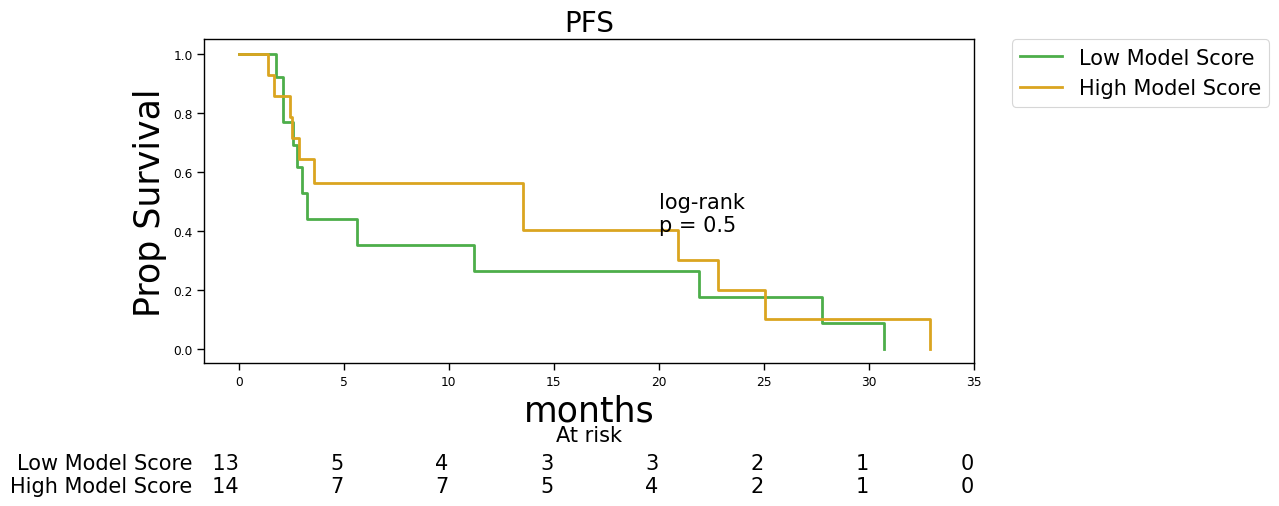

In [70]:
# Fig 5e - survival of model score-high and model score-low ipi-experienced tumors
from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts

#survival = 'OS'
survival = 'PFS'
#event = 'dead'
event = 'progressed'

sns.set_context("paper",font_scale=1)

groups = [ipiExpLower,ipiExpUpper]
#groups = [ipiNaiveLower,ipiNaiveUpper]
labels = ['Low Model Score','High Model Score']

groupColors = [CR_COL, PD_COL]

fig = plt.figure(figsize=(10,5))
kmfs = [] 
ax = plt.subplot()

i=0
ind = []
indLabels = []
for group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(fullDF.loc[group,survival]/30., fullDF.loc[group,event], label = labels[i])
    kmf.plot(ax=ax, ci_show = False, linewidth=2.0, color=groupColors[i])
    indLabels += [labels[i]] * len(group) # create labels for each individual
    ind += list(group)
    print(labels[i], ":", len(group))
    # print(survival,"median", kmf.median_)
    i+=1
    kmfs += [kmf]
    
# add at risk numbers below
# set xticks to start at 0
newxticks = []
for x in ax.get_xticks():
    if x >= 0:
        newxticks += [x]
print(newxticks)
ax.set_xticks(newxticks)

add_at_risk_counts_CUSTOM(kmfs[0], kmfs[1], ax=ax, fontsize=20, labels=labels)

    
ax.set_xlabel("months", fontsize = 25)

ax.set_ylabel("Prop Survival", fontsize = 25)
ax.legend(prop={'size':15}, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(survival, fontsize=20)

results = multivariate_logrank_test(fullDF.loc[ind,survival], 
                                    indLabels, 
                                    fullDF.loc[ind,event])
plt.text(20, 0.4, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)

results.print_summary()

Low Model Score : 13
High Model Score : 14
[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0]
['Low Model Score   13\nHigh Model Score   14', '13\n12', '11\n9', '10\n9', '9\n8', '8\n4', '5\n2', '1\n0', '0\n0']


/tmp/ipykernel_3831421/859139261.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(20, 0.4, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           1.53 0.22      2.21

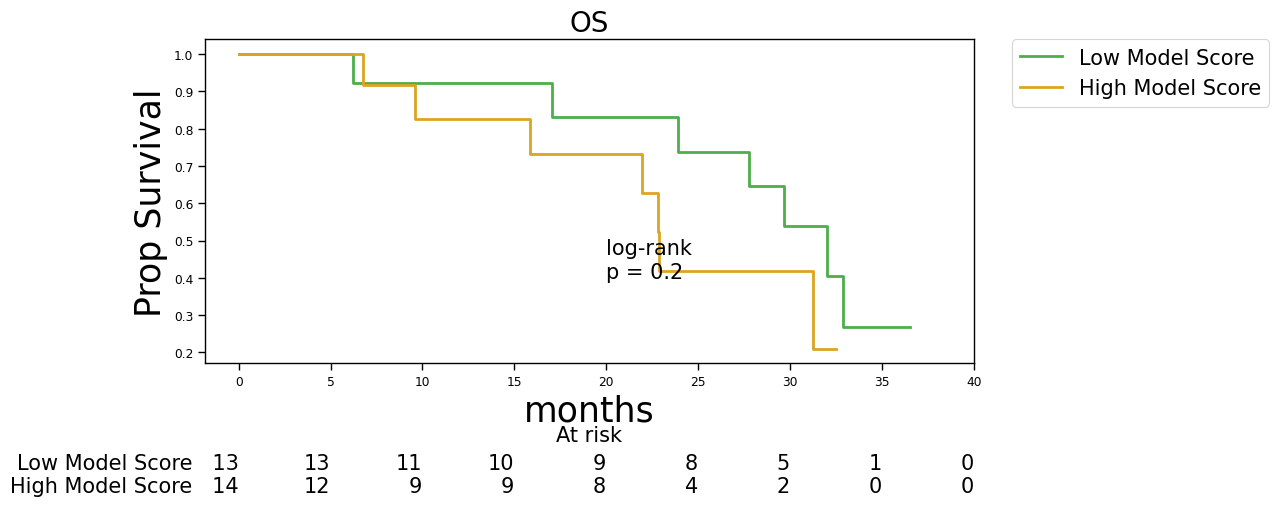

In [71]:
survival = 'OS'
#survival = 'PFS'
event = 'dead'
#event = 'progressed'

sns.set_context("paper",font_scale=1)

groups = [ipiExpLower,ipiExpUpper]
#groups = [ipiNaiveLower,ipiNaiveUpper]
labels = ['Low Model Score','High Model Score']

groupColors = [CR_COL, PD_COL]

fig = plt.figure(figsize=(10,5))
kmfs = [] 
ax = plt.subplot()

i=0
ind = []
indLabels = []
for group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(fullDF.loc[group,survival]/30., fullDF.loc[group,event], label = labels[i])
    kmf.plot(ax=ax, ci_show = False, linewidth=2.0, color=groupColors[i])
    indLabels += [labels[i]] * len(group) # create labels for each individual
    ind += list(group)
    print(labels[i], ":", len(group))
    # print survival,"median", kmf.median_
    i+=1
    kmfs += [kmf]
    
# add at risk numbers below
# set xticks to start at 0
newxticks = []
for x in ax.get_xticks():
    if x >= 0:
        newxticks += [x]
print(newxticks)
ax.set_xticks(newxticks)

add_at_risk_counts_CUSTOM(kmfs[0], kmfs[1], ax=ax, fontsize=20, labels=labels)

    
ax.set_xlabel("months", fontsize = 25)

ax.set_ylabel("Prop Survival", fontsize = 25)
ax.legend(prop={'size':15}, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(survival, fontsize=20)

results = multivariate_logrank_test(fullDF.loc[ind,survival], 
                                    indLabels, 
                                    fullDF.loc[ind,event])
plt.text(20, 0.4, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)

results.print_summary()

['Low Model Score   42\nHigh Model Score   43', '21\n17', '15\n11', '6\n5', '2\n1', '1\n1', '0\n0']


/tmp/ipykernel_3831421/460001644.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(20, 0.8, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.48 0.49      1.03

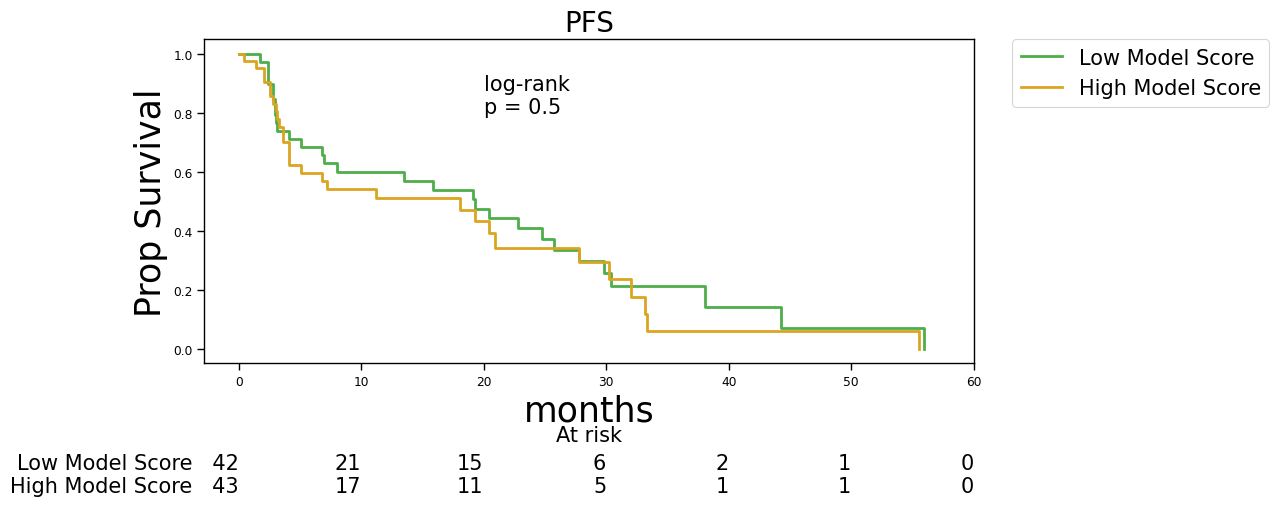

In [72]:
# Fig 5f - survival of model score-high and model score-low ipi-naive tumors

#survival = 'OS'
survival = 'PFS'
#event = 'dead'
event = 'progressed'

sns.set_context("paper",font_scale=1)

#groups = [ipiExpLower,ipiExpUpper]
groups = [ipiNaiveLower,ipiNaiveUpper]
labels = ['Low Model Score','High Model Score']

groupColors = [CR_COL, PD_COL]

fig = plt.figure(figsize=(10,5))
kmfs = [] 
ax = plt.subplot()

i=0
ind = []
indLabels = []
for group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(fullDF.loc[group,survival]/30., fullDF.loc[group,event], label = labels[i])
    kmf.plot(ax=ax, ci_show = False, linewidth=2.0, color=groupColors[i])
    indLabels += [labels[i]] * len(group) # create labels for each individual
    ind += list(group)
    # print labels[i], ":", len(group)
    # print survival,"median", kmf.median_
    i+=1
    kmfs += [kmf]
    
# add at risk numbers below
# set xticks to start at 0
newxticks = []
for x in ax.get_xticks():
    if x >= 0:
        newxticks += [x]
# print newxticks
ax.set_xticks(newxticks)

add_at_risk_counts_CUSTOM(kmfs[0], kmfs[1], ax=ax, fontsize=20, labels=labels)

    
ax.set_xlabel("months", fontsize = 25)

ax.set_ylabel("Prop Survival", fontsize = 25)
ax.legend(prop={'size':15}, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(survival, fontsize=20)

results = multivariate_logrank_test(fullDF.loc[ind,survival], 
                                    indLabels, 
                                    fullDF.loc[ind,event])
plt.text(20, 0.8, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)

results.print_summary()

['Low Model Score   42\nHigh Model Score   43', '33\n26', '24\n21', '12\n7', '3\n0', '2\n0', '0\n0']


/tmp/ipykernel_3831421/4135133268.py:55: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.text(20, 0.6, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           4.85 0.03      5.18

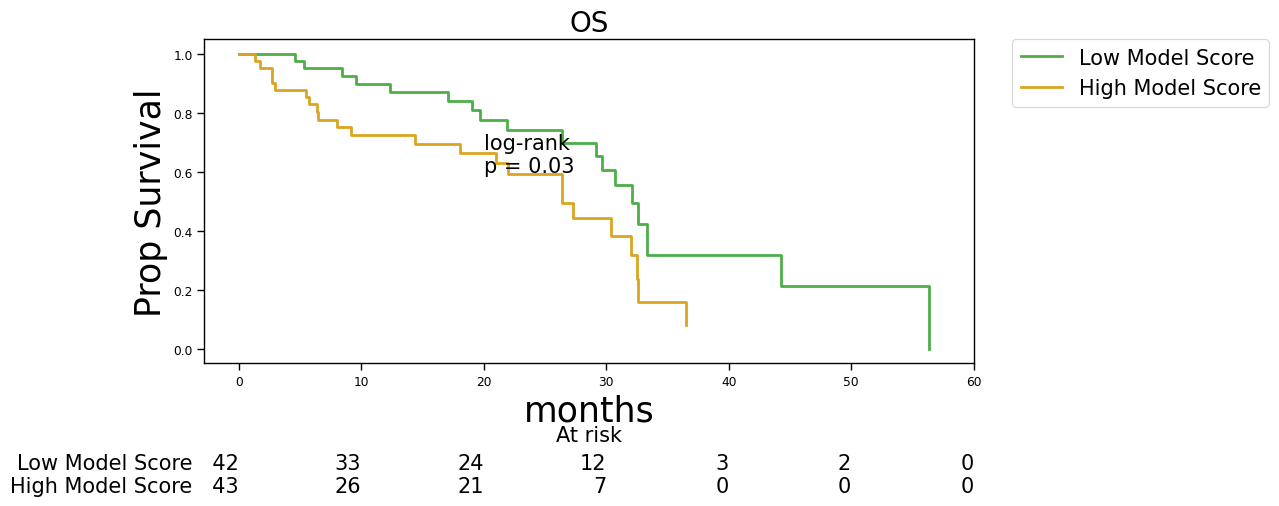

In [73]:
# Fig 5f - survival of model score-high and model score-low ipi-naive tumors

survival = 'OS'
#survival = 'PFS'
event = 'dead'
#event = 'progressed'

sns.set_context("paper",font_scale=1)

#groups = [ipiExpLower,ipiExpUpper]
groups = [ipiNaiveLower,ipiNaiveUpper]
labels = ['Low Model Score','High Model Score']

groupColors = [CR_COL, PD_COL]

fig = plt.figure(figsize=(10,5))
kmfs = [] 
ax = plt.subplot()

i=0
ind = []
indLabels = []
for group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(fullDF.loc[group,survival]/30., fullDF.loc[group,event], label = labels[i])
    kmf.plot(ax=ax, ci_show = False, linewidth=2.0, color=groupColors[i])
    indLabels += [labels[i]] * len(group) # create labels for each individual
    ind += list(group)
    # print labels[i], ":", len(group)
    # print survival,"median", kmf.median_
    i+=1
    kmfs += [kmf]
    
# add at risk numbers below
# set xticks to start at 0
newxticks = []
for x in ax.get_xticks():
    if x >= 0:
        newxticks += [x]
# print newxticks
ax.set_xticks(newxticks)

add_at_risk_counts_CUSTOM(kmfs[0], kmfs[1], ax=ax, fontsize=20, labels=labels)

    
ax.set_xlabel("months", fontsize = 25)

ax.set_ylabel("Prop Survival", fontsize = 25)
ax.legend(prop={'size':15}, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(survival, fontsize=20)

results = multivariate_logrank_test(fullDF.loc[ind,survival], 
                                    indLabels, 
                                    fullDF.loc[ind,event])
plt.text(20, 0.6, "log-rank\np = %0.1g" % results.summary['p'], fontsize=15)

results.print_summary()